# Single-contact spike detection (Real Data, CH19)
**The Goal** is to detect the firing of one known nerve fibre in a real rat saphenous nerve recording. This notebook only experiments on one channel, which is channel19. 
**The ground truth**: the lab marked 1,623 spikes for this unit. Here, the detections were tested against those markes. 
**The code difficulty encountered in this notebook in five ways:** the electrode picks up many fibres at once, so on a single channel  its diffecult to tell which fibre a given spike came from.
## Notebook Order


# Glossary 
## Windows
| Window | Code | What is measures | Between |
|----|----|----|----|
| 3 ms refractory | 'distance=90' | minimum gap so one spike is not counted twice | detection <-> detection|
| +/-2ms tolerance (field standard) | 'tolerance=0.002' in 'score_detection' | how close a detection must be to a true spike to be scored as correct | detection <-> ground_truth |
| 8 ms latency window | 'lat_min 96.1, lat_max=104.1' in 'in_latency_window' | whether detection falls in the fixed delay after the stimulus | detection<-> stimulus|
-----------------------------------------------------------------------------------------------------
## Variables
| Variable | Type | Size | what it holds |
|----|----|----|----|
| 'scores' | ndarray | 27,000,000 | match score at every sample (-1 to 1) |
| 'peaks' | ndarray | 193,458 | sample posittion where score peaked (intergers) |
| 'peak_times' | ndarray | 193,458 | time of each peak in seconds |
| 'ground_truth_in_window' | ndarray | 177 | true spike times in seconds |
|'sample_frequency' | number | 1 | 30000, sample per seconnd |
| 'window_start' | number | 1 | 3602.6708, recording start time in seconds |


In [55]:
#imports 
import sys

import numpy as np
import matplotlib.pyplot as plt
import h5py

from scipy.signal import correlate, find_peaks
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn import svm
from scipy.signal import resample
from scipy.ndimage import uniform_filter1d
from sklearn.svm import OneClassSVM
import torch
import torch.nn as nn
import pywt

path = r"C:\spike-denoising-synthetic\data\real"
sample_frequency = 30000 

# 1. Setup and data 
Load the recording and the ground truth. The data is one file per channel (float64, 30 kHz), already filtered (300-6000 Hz), and artefacts were blanked by the lab. 
ground truth is a MATLAB v7.3 file, and read by h5py

Here I worked on a 900-second window starting at stimulus 900, which is a stable stretch of the recording. All the times share one clock, and this was verified against time_series_2.bin (starts at 1.03s, 30 kHz spacing)
# Files:
 1. ***All times are in seconds. Recording is ~2.3 hours (8269 s) at 30 kHz***
 2. ***The recording's first sample sits at t = 1.03 s (see time_series_2.bin)***
## time_series_2.bin:
1. Time axis: one timestamp per sample, 248,074,240 values total.
2. Runs from 1.03 s (first sample) to 8270.17 s (last sample), stepping by 1/30000 s. Confirms the 30 kHz sampling rate.

## 100_RhythmData_..._CH19_..._filtered_blanked.bin
1. The CH19 voltage signal (float64). Already common-average-referenced (median), bandpass filtered (300-6000 Hz), and stimulus-blanked (artefacts set to the mean). Full length 248,074,240 samples (~2.3 h).
2. Loaded here as `ch19`: a 900 s window  starting at the 900th TTL pulse (window_start ~= 3602.7 s).

## TTLs_2.bin
1. Stimulus pulse times (float64), range 2.0 to 8269.1 s.
2. Delivered every ~4.0007 s. 189 pulses fall in the 900 s window.

## grouped_unit_1.mat
1. The "good" unit (target fibre): large spikes appearing on multiple channels (CH3, CH9, CH10, CH14, CH19, CH25, CH30 = same fibre seen on several channels).
2. Spike times are under CH**/aligned_zc_locs, marked at the zero-crossing. CH19 has 1623 spikes over the whole recording; 177 fall inside the 900 s analysis window.


In [2]:
#Load the ground truth
ground_truth = h5py.File(path + r"\grouped_unit_1.mat", "r") # Describes the time point of a "good" unit which has large spikes
print("List of field names inside the file:", [k for k in ground_truth.keys() if not k.startswith("#")])
zc_ch19 = ground_truth["CH19"]["aligned_zc_locs"][:].flatten() # aligned zero-crossing locations

print("Spikes on CH19:", len(zc_ch19)) # ground truth spikes
print("time range (s): %.1f to %.1f" % (zc_ch19.min(), zc_ch19.max())) # 

List of field names inside the file: ['CH10', 'CH14', 'CH19', 'CH25', 'CH3', 'CH30', 'CH9', 'filename', 'group_number', 'primary_channel']
Spikes on CH19: 1623
time range (s): 1754.5 to 8265.2


In [3]:
# Define the window
ttls = np.fromfile(path + r"\TTLs_2.bin", dtype='<f8') # load stimulus pulse times from the file 

print("number of TTLs:", len(ttls)) # totsal stimulus pulses in the whole recording
print("spacing (s):", np.diff(ttls[:5])) # The gap between the first five pulses

# MATLAB counts from 1, PYTHON from 0
print("ttls[792]:", ttls[792])  
print("ttls[900]:", ttls[900]) 

window_start = ttls[900]   # the time of pulse index 900, so the 900-second window begins at the 900th stimulus pulse 
window_end   = window_start + 900 #900 s= 15 minutes

print("window: %.2f to %.2f s" % (window_start, window_end)) # print window starta nd end time
print("stimuli in window:", ((ttls >= window_start) & (ttls <= window_end)).sum()) # count how many stimulus pulses in side the 900 second window

number of TTLs: 2310
spacing (s): [4.0007     4.0007     4.00073333 4.0007    ]
ttls[792]: 3170.5945666666667
ttls[900]: 3602.6708
window: 3602.67 to 4502.67 s
stimuli in window: 189


In [4]:
print("CH19 spike times range: %.1f to %.1f s" % (zc_ch19.min(), zc_ch19.max()))
print("recording length: %.1f s" % (248074240 / sample_frequency))

CH19 spike times range: 1754.5 to 8265.2 s
recording length: 8269.1 s


In [5]:
import numpy as np
ts = np.fromfile(path + r"\time_series_2.bin", dtype='<f8')
print("time_series length:", len(ts))
print("first values:", ts[:5])
print("last values:", ts[-5:])

time_series length: 248074240
first values: [1.03       1.03003333 1.03006667 1.0301     1.03013333]
last values: [8270.17116667 8270.1712     8270.17123333 8270.17126667 8270.1713    ]


In [6]:
print("TTLs range: %.1f to %.1f s" % (ttls.min(), ttls.max()))
print("window: %.1f to %.1f s" % (window_start, window_end))

TTLs range: 2.0 to 8269.1 s
window: 3602.7 to 4502.7 s


## The loaded window:
27000000 samples (900 s), noise floor MAD 4.96, 177 ground truth spikes inside the window. These are what every method below is scored against

In [7]:
# Load CH19 for the 900-second (15-minute) window
ch19_file = path + r"\100_RhythmData_CH19_2_filtered_blanked.bin"   # prefiltered and artefact blanked
start_indx = int(window_start * sample_frequency)   # window start time -> sample index
n_samples = int(900 * sample_frequency)             # 900 s x 30000 Hz = 27,000,000 samples
ch19 = np.fromfile(ch19_file, dtype='<f8', count=n_samples, offset=start_indx * 8)   # load ch19 for this window
window_end = window_start + len(ch19) / sample_frequency
noise_mad = np.median(np.abs(ch19)) / 0.6745        # noise estimate for this window
ground_truth_in_window = zc_ch19[(zc_ch19 >= window_start) & (zc_ch19 <= window_end)]   # ground-truth spikes in the window
print("samples loaded:", len(ch19))                 # expect 27,000,000
print("seconds: %.1f" % (len(ch19) / sample_frequency))   # expect 900
print("noise (MAD): %.2f" % noise_mad)
print("ground-truth spikes in window:", len(ground_truth_in_window))

samples loaded: 27000000
seconds: 900.0
noise (MAD): 4.96
ground-truth spikes in window: 177


# 2. Characterise the spikes
This section measures how deep the ground truth spikes are. 
To look at the depth of the spike:
To hold a full spike, a 3 ms clip is chosen; 3 ms at 30 kHz is 90 samples.  

**A spike is captured in a 3 ms window. At the 30 kHz sampling rate, 3 ms corresponds to 90 samples (0.003 s × 30 000 = 90). This window is centred on the spike, with half_width = 45 samples (1.5 ms) taken on each side.**

In Extracellular recordings that measure extracellular potentials, when an axon fires an action potential, positive sodium ions rush into the cell at the active region. This leaves the extracellular space near the electrode locally negative, which the electrode records as a downward deflection. So, because of the negative-going spike amplitudes: **(5th Percentile)** is the lowest numerical value, meaning it is the largest negative drop. Physically, representing deepest, the highest-amplitude, strongest spikes (furthest away from 0).**(95th Percentile)**: This is closer to zero and represents the shallowest, smallest spikes that sit right on the edge of the background noise floor.

Once the absolute value is taken in the code (np.abs(depths)), these mathematical positions flip, on the transformed positive scale, where the 5th percentile becomes the shallow spikes and the 95th percentile becomes the deep spikes

In [8]:
# Characterise the spikes: for each ground truth spike time in the window, convert to a sample index
half_width = 45  # Samples to take each side of each spike. 45 samples = 1.5ms at 30 kHz. 

depths = [] # empty list to collect each spike's depth
for spike_time in ground_truth_in_window:
    spike_index = int((spike_time - window_start) * sample_frequency)  # Convert this spike's time to a sample index within the loaded window 
                                                    # Find where a spike sits inside ch19, subtract the window's start time, then multiply by the frequency.  
    
    spike_segment = ch19[spike_index - half_width : spike_index + half_width] # Cut a 90 sample window out of Ch19 centred on the spike. 
    if len(spike_segment) == 2 * half_width:  # Only keep full length segments, so skip spikes too close to the window edge to cut a full 90 samples
        depths.append(spike_segment.min()) 
depths = np.array(depths) # The trough of each spike
ratios = np.abs(depths) / noise_mad # each depth divided by the MAD noise floor, so how many times the noise level each spike goes. 

print("spikes measured:", len(depths)) # How many spikes got meausred 
print("median depth: %.2f (%.2f x noise)" % (np.median(depths), np.median(ratios))) # median depth and median depth relative to the noise
print("5th percentile:  %.2f x noise" % np.percentile(ratios, 5)) #shallow spikes 
print("95th percentile: %.2f x noise" % np.percentile(ratios, 95)) # deepest spikes

spikes measured: 177
median depth: -11.12 (2.24 x noise)
5th percentile:  1.51 x noise
95th percentile: 3.48 x noise


In [9]:
# Inter-spike interval (ISI) check on the target ground-truth spikes.
# ISI is the time gap between two consecutive spikes from the same unit.
# A neuron has a refractory period (it can't fire again immediately after a spike), so two real spikes from one fibre can not be closer than that period.
# counting ISIs checks any violation shorter than the refractory period, so many violations mean the unit is contaminated with spikes from other fibres. 
isi = np.diff(np.sort(ground_truth_in_window))   # time between consecutive target spikes (seconds)

print("number of target spikes:", len(ground_truth_in_window))
print("number of ISIs:", len(isi))
print("shortest ISI (ms): %.2f" % (isi.min() * 1000))
print("median ISI (s): %.3f" % np.median(isi))
print("longest ISI (s): %.3f" % isi.max())

# refractory check: how many ISIs are shorter than a refractory period
refractory_ms = 3
violations = (isi < refractory_ms / 1000).sum()
print(f"ISI violations (< {refractory_ms} ms):", violations, 
      "(%.2f%%)" % (100 * violations / len(isi)))

number of target spikes: 177
number of ISIs: 176
shortest ISI (ms): 2000.33
median ISI (s): 4.001
longest ISI (s): 128.756
ISI violations (< 3 ms): 0 (0.00%)


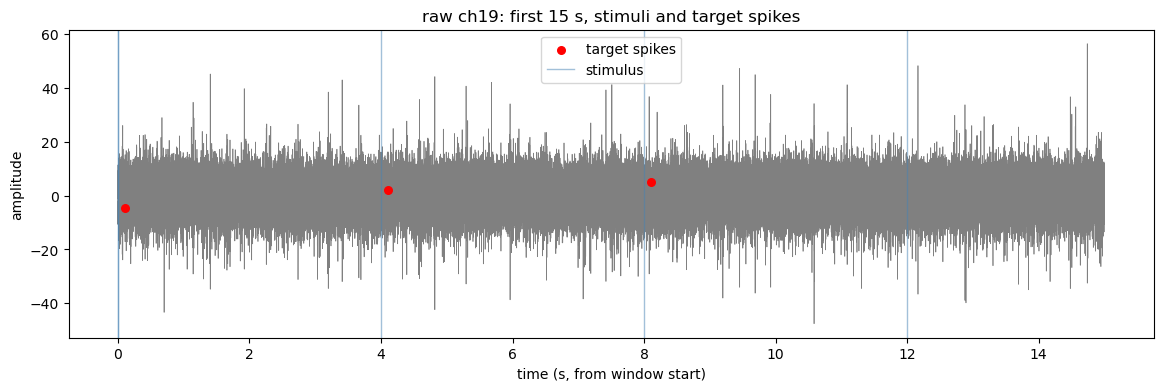

In [10]:
slice_seconds = 15                                    # how many seconds to show
n = int(slice_seconds * sample_frequency)             # that many samples
trace = ch19[:n]                                       # first 15 s of the windowed signal
time_axis = np.arange(n) / sample_frequency            # x-axis in seconds (0 to 15), relative to window_start

# stimuli and target spikes that fall inside this slice (times are absolute, so subtract window_start)
stim_in_slice   = ttls[(ttls >= window_start) & (ttls < window_start + slice_seconds)] - window_start
target_in_slice = ground_truth_in_window[(ground_truth_in_window >= window_start) &
                                          (ground_truth_in_window < window_start + slice_seconds)] - window_start

# amplitude at each target spike, so the dot sits on the trace
target_samples = np.round(target_in_slice * sample_frequency).astype(int)
target_amp = trace[target_samples]

plt.figure(figsize=(14, 4))
plt.plot(time_axis, trace, color="gray", lw=0.5)                      # the raw voltage trace
for t in stim_in_slice:
    plt.axvline(t, color="steelblue", alpha=0.5, lw=1)               # a line at each stimulus
plt.scatter(target_in_slice, target_amp, color="red", s=30, zorder=3, label="target spikes")
plt.axvline(stim_in_slice[0], color="steelblue", alpha=0.5, lw=1, label="stimulus")  # one labelled line for the legend
plt.xlabel("time (s, from window start)")
plt.ylabel("amplitude")
plt.title(f"raw ch19: first {slice_seconds} s, stimuli and target spikes")
plt.legend()
plt.show()

# 3. Detection by depth
This part is in three stages: 
First, detect spikes: find where the signal first dips below -k x noise, drop any dip that starts closer than 3 ms to the previous kept one and return the survivors as times in seconds.
**crossings:** contains everything that crossed the threshold.
**keep:** then it holds only the crossings from that list that are at least 90 samples after the last kept crossing (the refractory 3 ms) to remove duplicates.

Second, for each detection score, look for a nearby unclaimed true spike; if found, count a hit and claim that spike; then count the hits, false alarms, and misses and turn them into precision, recall and F1.
NOTE: The detector runs two rules:
1. threshold: signal drops below -1.5 x noise floor -> detect
2. Refractory: after a detection, ignore everything for ms to prevent counting the same spike more than once

Third, threshold sweep for detection
It tests the amplitude detector at five different threshold strengths and scores each one against the ground truth to see how detection quality changes as the threshold gets stricter. 

## Results: 
Detected spikes: ~229,677 at k=1.5 down to ~16,682 at k=4
Recall: 0.921 at k=1.5 to ~0.051 at k=4
Precision: stays flat near zero 
F1: 0.001 across all thresholds. 

## Opinion:
If false positives are noise, when the threshold is raised, it would have removed them and returned high precision. But precision stays near zero regardless of how strict the threshold is. This suggests that false positives are not noise but other fibres with similar amplitude to the target unit that cross the threshold at every k. 


In [11]:
# Helper functions for finding the spikes and scoring them against the ground truth in the window. 
def detect_spikes(data, sample_frequency, k=4, noise_std=None, refractory_ms=3.0):
    """
    Detect spikes by amplitude threshold on a negative-going signal.
    Flag every point where the signal drops below -k * noise, then enforces a refractory period so a single spike crossing the threshold more than once its counted as one

    Args:
        data (np.ndarray): 1D signal (one channel)
        sample_frequency (int): sampling rate in Hz (30000)
        k (float): threshold multiplier; lower catches more, higher is stricter. 
        noise_std (float or None): noise level; if None, estimated as MAD = median(|data|)/0.6745.
        refractory_ms (float): minimum gap between detections in ms.
    """
    if noise_std is None:
        noise_std = np.median(np.abs(data)) / 0.6745 # MAD: absolute value of every sample, take the median, divide by 0.6745
    threshold = -k * noise_std     # the cutoff a sample must go below to count
    below = data < threshold       # boolean mask, True where the signal is below the threshold
    crossings = np.where(np.diff(below.astype(int)) == 1)[0] + 1 # find the start of each dip, turn True/flase into 1/0; below the threshold is 1, above is 0. so, when 0 -> 1 = signal first drops below the line 
                                                                # np.diff() subtract each sample from the next, so a step from 0 up to 1 shows as +1 and 1 to 0 as -1. 
                                                                # == 1 keeps only the +1
                                                                # np.where()[0] returns the index position where that is true
                                                                # +1 shifts each index forward by one, because np.diff reports a change at the sample just before it happens
    min_gap = int(refractory_ms * sample_frequency / 1000)  # refractory period in samples (3ms -> 90)
    keep = []  # collect kept crossings
    last = -min_gap # index of the last kept crossing
    for crossing in crossings: 
        if crossing - last >= min_gap: # keep the crossings only if it's at least 90 samples after the last kept one, if kept 
            keep.append(crossing)      
            last = crossing        #if kept, record it and update
    return np.array(keep) / sample_frequency  # The kept values are divided by the sample frequency (30000), which turns them into seconds. 

def score_detections(detected, ground_truth_times, tolerance=0.002): 
    """
    Score detections against ground truth spike times
    Each detection is matched to a ground truth spike within tolerance.

    Args:
        detected (np.ndarray): detection times in seconds 
        ground_truth_times (np.ndarray): ground truth target spike times in seconds 
        tolerance (float): match window in seconds (e.g. 0.001 = +/- 1 ms)

    Returns:
            tuple(float, float, float): precision, recall, f1
                precision = tp/(tp+fp), recall = tp/(tp+fn), f1 = harmonic mean
    """
    matched_true = set() # A set that remembers which true spikes have already been claimed by a detection 
    tp = 0  # True-positive counter (hits) starts at 0
    for detection in detected: # Go through each detection
        close = np.where(np.abs(ground_truth_times - detection) <= tolerance)[0] # find true spiks near tis detection
        unmatched = [ground_truth_index for ground_truth_index in close if ground_truth_index not in matched_true] # Of those nearby true spikes, only keep the ones that are not already claimed by an earlier detection. 
        if len(unmatched) > 0: # if there's at least one unclaimed true spike nearby, this detection is a hit:
            tp += 1                        # count it as a true positive
            matched_true.add(unmatched[0]) # claim the first available true spike (mark it used,so no other detection can claim it) 
    fp = len(detected) - tp # false positives = detections that didn't hit anything (total detections - the hits)
    fn = len(ground_truth_times) - len(matched_true) # false negative = true spikes that got missed. Total true spikes - the ones that got claimed. 
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0 # precision = of everything detected, how many were real. 
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0 # Recall = of all the true spikes, how many were caught 
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0 # F1 = the harmonic mean of precision and recall. 
    return precision, recall, f1

In [12]:
# threshold detection sweep
# Run amplitude detector at five different thresholds and score each one
print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}") 
for k in [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]: # low k (0.5) = loose threshold catches lots of spikes. High k (4) is strict, so it only catches bigger dips. 
    #  detect at this threshold
    depth_detections = detect_spikes(ch19, sample_frequency, k=k) + window_start # run detector on the signal at this k, returs detetcions times relative to the window start
    precision, recall, f1 = score_detections(depth_detections, ground_truth_in_window, tolerance=0.002) # compare the detections to the ground truth spikes, with a +/- 2ms match window and return three mertics for this k.
    print(f"{k:5.1f} {len(depth_detections):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")
    if k == 1.5:
        number_detections_depth = len(depth_detections)
        precision_depth = precision
        recall_depth = recall
        f1_depth = f1

    k  detected  precision   recall      F1
  0.5    274924     0.0006    1.000   0.001
  1.0    261085     0.0007    0.983   0.001
  1.5    229677     0.0007    0.921   0.001
  2.0    170811     0.0007    0.701   0.001
  2.5    102178     0.0007    0.418   0.001
  3.0     53703     0.0007    0.209   0.001
  3.5     28548     0.0005    0.073   0.001
  4.0     16682     0.0005    0.051   0.001


# 4. Template Matching (Detection by shape)
### Threshold detection alone did not tell the target spike from other events, so this stage matches on shape instead of depth. 
This section, uses normalised cross-correlation trough aligned template (aligns each spike ot its trough) by building one average spike waveform (the template) from the 177 ground truth spikes. 
1. **Template_match** slides the template along the whole recording and, at every sample, measures how similar the signal there is to the template shape, and the output is a score at every sample running from -1 to +1, where high means the signal looks like a spike.
2. The score is a normalised correlation (Pearson), so it responds to shape, not amplitude, so a big spike and a small spike with the same shape both score high.
3. **find_peaks(scores, height=0.3, distance=90)**: finds the peaks in the score signal: local maxima at least 0.3 high and at least 90 samples (3ms refractory) apart, which converts the continuous score into a list of discrete detection positions. 



In [178]:
#helper function for template matching

def template_match(signal, template):
    """
    Normalised cross-correlation between template and a signal
    Slides the zero-mean, unit-norm template along the signal and returns a match score at every sample. 

    Args:
        signal (np. ndarray): 1D signal to search
        template (np.ndarray): the average spike waveform to match. 

    Return:
        np.ndarray: match score in [-1, 1] at each sample.
    """
    template_centred = template - template.mean() #subtract the average so the template sits centred on zero, with equal weight above and below 
    template_unit = template_centred / np.linalg.norm(template_centred) # divide by its length (the square root of the sum of squared), so the template size 1 
                            # zero means removes the offset and unit norm removes the scale, together they turn a raw dot product into a proper correlation that lives in [-1. 1]
    template_length = len(template_unit) # template length in samples. 
    raw_match = correlate(signal, template_unit, mode='same') # At every position along the signal, slide the template, multiply and sum template against signal at every position, and give one value per sample. 
    
    # Measure the signal's size at every position, how big the signal is in each template width window. 
    local_mean   = uniform_filter1d(signal,    template_length, mode='nearest') # signal's local mean. Slide a window of width along the signal and average the values inside it.                                                   
    local_mean_sqr  = uniform_filter1d(signal**2, template_length, mode='nearest') #local mean of the signal squared
    local_variance = np.maximum(local_mean_sqr - local_mean**2, 0)  #local variance = (mean of squares) - (mean squared) and clipped at 0, so rounding cant make it negatie
    local_norm = np.sqrt(local_variance * template_length) 
    return np.divide(raw_match, local_norm, out=np.zeros_like(raw_match), where=local_norm > 1e-6) # Raw match / signal size = the final shape score [-1, 1]

def spike_latencies(spike_times, ttls):
    """
    Latency of each spike from the stimulus pulse
    For each spike, finds the most recent stimulus (TTL) before it and returns the time difference. 

    Args:
        spike_times (np.ndarray): spike times in seconds
        ttls (np.ndarray): stimulus pulse times in seconds

    returns :
        latency of each true spike in seconds
    """
    indx = np.searchsorted(ttls, spike_times) - 1
    ok = indx >= 0
    lat = spike_times[ok] - ttls[indx[ok]]
    return lat

# The latency constraint 
def in_latency_window(times, ttls, lat_min=0.085, lat_max=0.160):
    """
    for each detection, True if it fired at the right delay after a stimulus (between lat_min and lat_max), 
    false otherwise
    
    Args:
        times (np.ndarray): detection times in seconds 
        ttls (np.ndarray): stimulus pulse times in seconds
        lat_min (float): lower latency bound in seconds
        lat_max (float): upper latency bound in seconds

    return:
        np.ndarray: true where the detection's latency falls in the window
        The wide window (0.085-0.160); the tight bound is passed for a 8 ms window.  
    """
    indx = np.searchsorted(ttls, times) - 1
    has_ttl = indx >= 0
    latency = np.full(len(times), np.inf)
    latency[has_ttl] = times[has_ttl] - ttls[indx[has_ttl]]
    return (latency >= lat_min) & (latency <= lat_max)

def score_detections_counts(detected, ground_truth_times, tolerance=0.002):
    """
    score detection to return tp, fp, fn
    """
    matched_true = set()
    tp = 0
    for detection in detected:
        close = np.where(np.abs(ground_truth_times - detection) <= tolerance)[0]
        unmatched = [gt for gt in close if gt not in matched_true]
        if len(unmatched) > 0:
            tp += 1
            matched_true.add(unmatched[0])
    fp = len(detected) - tp
    fn = len(ground_truth_times) - len(matched_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fptp = fp / tp if tp > 0 else float('inf')
    return tp, fp, fn, precision, recall, f1, fptp
    

In [14]:
# Build the template
half_width   = 45      # 1.5 ms template width on each side of the trough
align_window = 30      # 1 ms to find the real trough, because the marked spike times might be a bit off the true deepest point. 

spike_segments = [] # holds one clip per spike
for spike_time in ground_truth_in_window: # convert spike's time (seconds) to sample index in ch19: subtract the window start
    centre_index = int((spike_time - window_start) * sample_frequency) # then multiply by sample frequency to turn seconds into samples
    
    # cut a chunk wider than the final clip, leaving room to search for the trough
    lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window
    if lo < 0 or hi > len(ch19): # skip spikes that are too near the recording edge
        continue
    wide_window   = ch19[lo:hi]
    # look in align_window each side of the centre, find the deepest sample (the trough)
    centre = half_width + align_window # middle of the wide_window where the marked spike sits
    trough_index = np.argmin(wide_window[centre - align_window : centre + align_window]) + (centre - align_window)
    
    # Cut 45 samples each side of the trough, a 90 sample clip centred on the deepest point. 
    spike_segment = wide_window[trough_index - half_width : trough_index + half_width]
    if len(spike_segment) == 2 * half_width:
        spike_segments.append(spike_segment)

spike_segments = np.array(spike_segments) # Stack all the clips into an array, then average down the columns. 
template = spike_segments.mean(axis=0) # the average is the template. 

print("spikes averaged:", len(spike_segments))  
print("template trough: %.2f" % template.min())
print("trough / noise:  %.2f" % (abs(template.min()) / noise_mad)) # how deep is the spike compared to the noise. 

spikes averaged: 177
template trough: -11.04
trough / noise:  2.23


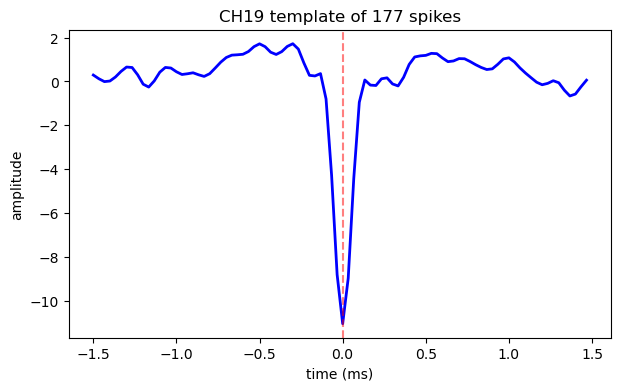

In [15]:
# plot the template 
time_ms = (np.arange(2 * half_width) - half_width) / sample_frequency * 1000
plt.figure(figsize=(7, 4))
plt.plot(time_ms, template, 'b', linewidth=2)
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('time (ms)'); plt.ylabel('amplitude')
plt.title('CH19 template of %d spikes' % len(spike_segments))
plt.show()

In [16]:
# Runthe over the whle signal and check the score range
scores = template_match(ch19, template)
print("score range: %.3f to %.3f" % (scores.min(), scores.max()))
print("zeroed samples:", (scores == 0).sum())

score range: -0.950 to 0.884
zeroed samples: 608


In [17]:
# Similarity threshold sweep 
# height=th is the shape similarity threshold: find_peaks keeps only peaks scoring at least th (-1 to +1). 
# Higher th = stricter match, so only spikes very similar to the template are kept
# Lower th = looser match, more peaks (more false positives). 

print(f"{'thresh':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]: # try five different similarity thresholds 
    peaks, _ = find_peaks(scores, height=th, distance=90) # find peaks in the match score signal. Only keep peaks scoring at least 'th' (threshold)  
    shape_detections = peaks / sample_frequency + window_start # Convert peak sample positions to absolute time in second
    precision, recall, f1 = score_detections(shape_detections, ground_truth_in_window, tolerance=0.002) # score this threshold's detections against the 177 true spikes, +/-2 ms match tolerence 
    print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

 thresh  detected  precision   recall      F1
    0.3    193458     0.0007    0.814   0.001
    0.4    149377     0.0008    0.644   0.002
    0.5     76525     0.0008    0.333   0.002
    0.6     25838     0.0007    0.096   0.001
    0.7      5536     0.0011    0.034   0.002


## 5. Latency constraint
Template matching (shape) kept the target spikes but also detected other events, so precision is low, as seen in the similarity scores above. The target fibres fire at a consistent delay after each stimulus, which other fibres do not share, so this latency constraint stage filters detections by timing to remove them. So the contrast and shape could not separate target spikes from other events, but timing can; this is the point of this section. 
### Three steps to do this:
1. **Measure each detection's latency**: for every detection, find the stimulus pulse just before it and measure the delay between them. That delay is the latency. 
2. **Only keep detections in the latency band**: so a detection is kept only if its latency falls within a window around the target's typical delay.
3. **Why that width**: An 8 ms width was chosen

### Results:

In [18]:
# Find the best latency window: centre on the median ground truth latency, and sweep the half_width
#in_latency_window expects seconds; lo/hi are converted to seconds (/1000) on their line
# both ground_truth_latency and median_latency are in ms

ground_truth_latency = spike_latencies(ground_truth_in_window, ttls) * 1000 # take the 177 target spikes and compute each one's latency and convert them from s to ms
median_latency = np.median(ground_truth_latency) 
peaks, _ = find_peaks(scores, height=0.3, distance=90) # scan the match score signal and return the sample positions of every shape match,
                                                    # that is both at least 0.3 strong and 90 samples (3ms) apart from the next 
print("shape detections (before latency:", len(peaks))
shape_detections = peaks / sample_frequency + window_start #convert those peak positions from sample indices into absolute times in seconds. 

print(f"{'window (ms)':>16s} {'width':>6s} {'kept':>6s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for latency_half_width in [0.5, 1.0, 1.5, 2, 2.5, 3, 3.5, 4, 5, 6, 7]: # try each half_width in turn in ms. How far each side of the median is accepted
    lo, hi = (median_latency - latency_half_width)/1000, (median_latency + latency_half_width)/1000 #lo = median minus the half_width, hi = median plus the half_width
                                                                                                    # both are converted from ms to seconds. 
    
    latency_detections = shape_detections[in_latency_window(shape_detections, ttls, lat_min=lo, lat_max=hi)] # only keep the shape detection where post stimulus latency falls in [lo, hi] 
    precision, recall, f1 = score_detections(latency_detections, ground_truth_in_window, tolerance=0.002) # score detections against the 177 ground truth spikes , +/- 2ms tolerance.
    print(f"  {median_latency-latency_half_width:.1f}-{median_latency+latency_half_width:.1f} {2*latency_half_width:6.0f} {len(latency_detections):6d} {precision:10.3f} {recall:8.3f} {f1:7.3f}")

shape detections (before latency: 193458
     window (ms)  width   kept  precision   recall      F1
  99.6-100.6      1     45      0.489    0.124   0.198
  99.1-101.1      2     87      0.437    0.215   0.288
  98.6-101.6      3    116      0.388    0.254   0.307
  98.1-102.1      4    161      0.373    0.339   0.355
  97.6-102.6      5    203      0.355    0.407   0.379
  97.1-103.1      6    245      0.359    0.497   0.417
  96.6-103.6      7    292      0.339    0.559   0.422
  96.1-104.1      8    329      0.334    0.621   0.435
  95.1-105.1     10    400      0.300    0.678   0.416
  94.1-106.1     12    490      0.276    0.763   0.405
  93.1-107.1     14    566      0.253    0.808   0.385


In [259]:
# Tight latency constraint
# Apply the chosen 8ms window (96.1-104.1)
tight_lo = (median_latency - 4) / 1000 # take the median latency, subtract 4 (half_width) to get the lower bound (97.6 ms), then convert ms to seconds
tight_hi = (median_latency + 4) / 1000 # same thing just median pluse 4
# Apply the constraint
tight_detections = shape_detections[in_latency_window(shape_detections, ttls, lat_min=tight_lo, lat_max=tight_hi)]
precision, recall, f1 = score_detections(tight_detections, ground_truth_in_window, tolerance=0.002) # score detection against thr 177 spikes 

tp = round(recall * len(ground_truth_in_window)) #target spikes caught
fp = len(tight_detections) - tp  # detections kepat that are not target spikes
fn = len(ground_truth_in_window) - tp # target spikes missed

print("tight latency window: %.1f-%.1f ms" % (median_latency - 4, median_latency + 4))
print("kept: %d   TP: %d   FP: %d   FN: %d" % (len(tight_detections), tp, fp, fn))
print("precision: %.3f   recall: %.3f   F1: %.3f" % (precision, recall, f1))

tight latency window: 96.1-104.1 ms
kept: 9   TP: 4   FP: 5   FN: 173
precision: 0.444   recall: 0.023   F1: 0.043


In [20]:
print("type:", type(scores))
print("shape:", scores.shape)
print("dtype:", scores.dtype)
print("first 5:", scores[:5])
print("min, max:", scores.min(), scores.max())

type: <class 'numpy.ndarray'>
shape: (27000000,)
dtype: float64
first 5: [-0.22462844 -0.23840451 -0.18554775 -0.07150159  0.05230744]
min, max: -0.949755091391741 0.8843374292099632


In [261]:
# Validation check
# check 1: does the time-to-index conversion land on a real spike
spike_time = ground_truth_in_window[0]# first true spike time
centre_index = int((spike_time - window_start) * sample_frequency) # where does the spike sit within the score array
print("first spike_time:", spike_time)
print("centre_index:", centre_index, " (a whole number, 0 to 27,000,000)") # the spike sits at what position
print("score at that idx:", scores[centre_index]) #what is the match score at that position? low = weak match, high = high match
print("max near it:", scores[centre_index-90:centre_index+90].max())# what about at a small window around the position, is there a match? 


first spike_time: 3602.7732333333333
centre_index: 3073  (a whole number, 0 to 27,000,000)
score at that idx: 0.06908561875168709
max near it: 0.44832209957782465


In [173]:
#validation check
print("ground_truth_in_window") 
print("type:", type(ground_truth_in_window))
print("len:", len(ground_truth_in_window))
print("first 5:", ground_truth_in_window[:5])
print("window_start")
print("value:", window_start)
print("sample_frequency")
print("  value:", sample_frequency)
print("scores")
print("len:", len(scores))
print("range:", scores.min(), "to", scores.max())

ground_truth_in_window
type: <class 'numpy.ndarray'>
len: 177
first 5: [3602.77323333 3606.7741     3610.7746     3618.77576667 3622.7765    ]
window_start
value: 3602.6708
sample_frequency
  value: 30000
scores
len: 27000000
range: -0.949755091391741 to 0.8843374292099632


In [174]:
# Shape threshold sweep with latency constraint applied to it
template = templates_by_signal["raw"]
scores = template_match(ch19, template)
print(f"{'thresh':>7s} {'kept':>6s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores, height=th, distance=90)
    shape_detections = peaks / sample_frequency + window_start
    #apply  the letency window 
    latency_kept = shape_detections[in_latency_window(shape_detections, ttls, lat_min=tight_lo, lat_max=tight_hi)]
    precision, recall, f1 = score_detections(latency_kept, ground_truth_in_window, tolerance=0.002)
    print(f"{th:7.1f} {len(latency_kept):6d} {precision:10.3f} {recall:8.3f} {f1:7.3f}")

 thresh   kept  precision   recall      F1
    0.2    353      0.323    0.644   0.430
    0.3    329      0.334    0.621   0.435
    0.4    253      0.336    0.480   0.395
    0.5    133      0.323    0.243   0.277
    0.6     42      0.262    0.062   0.100
    0.7      9      0.444    0.023   0.043


In [181]:
#baseline detection with TP/FP/FN and TP/TP similar to Troglio et al 2026
baseline = tight_detections_by_signal["raw"]
tp, fp, fn, precision, recall, f1, fptp = score_detections_counts(baseline, ground_truth_in_window, tolerance=0.002)
print(f"TP {tp}  FP {fp}  FN {fn}  precision {precision:.3f}  recall {recall:.3f}  f1 {f1:.3f}  FP/TP {fptp:.2f}")

TP 110  FP 219  FN 67  precision 0.334  recall 0.621  f1 0.435  FP/TP 1.99


In [186]:
#inter-detection intervals without a refractory
template = templates_by_signal["raw"]
scores = template_match(ch19, template)

# detect without the refractory (distance=1), shape threshold 0.3
peaks_no_refractory, _ = find_peaks(scores, height=0.3, distance=1)
peak_times = peaks_no_refractory / sample_frequency   # seconds

# inter-detection intervals gaps between consecutive detections in ms
intervals_ms = np.diff(peak_times) * 1000

print(f"detections without refractory: {len(peaks_no_refractory)}")
print(f"median interval: {np.median(intervals_ms):.2f} ms")
print(f"intervals under 3 ms: {(intervals_ms < 3).sum()} out of {len(intervals_ms)} ({100*(intervals_ms < 3).mean():.1f}%)")

detections without refractory: 556728
median interval: 1.50 ms
intervals under 3 ms: 509031 out of 556727 (91.4%)


In [26]:
def whats_inside(name, x):
    if np.isscalar(x):
        print(f"{name}: single value = {x}")
    else:
        print(f"{name}: {type(x).__name__}, length {len(x)}, first few {x[:3]}")

whats_inside("peaks", peaks)
whats_inside("peak_times", peak_times)
whats_inside("scores", scores)
whats_inside("is_target", is_target)
whats_inside("ground_truth_in_window", ground_truth_in_window)

peaks: ndarray, length 193458, first few [ 82 255 352]
peak_times: ndarray, length 193458, first few [3602.67353333 3602.6793     3602.68253333]
scores: ndarray, length 27000000, first few [-0.22462844 -0.23840451 -0.18554775]
is_target: ndarray, length 193458, first few [False False False]
ground_truth_in_window: ndarray, length 177, first few [3602.77323333 3606.7741     3610.7746    ]


# 6. One-Class SVM

In [27]:
# Helper function
# Trough aligned extraction: finds the trough and cuts the 90 sample waveform 
# Here every spike is centred the same way regardless of how it was marked
# this version is the one used for SVM because it fixes the misalignment 
half_width_svm = 45   # 45 samples each side = 90-sample waveform
def extract_aligned_waveform(spike_time, signal=None):
    """
    Cut a 90 sample waveform centred on the spike's trough (deepest point)
    Extract a wider window first (wider research window, 70 half width instead of 45), find the trough, then take 45 samples either side ot it. 
    return None if a spike is too close to the edge for the wide window 
    Args:
        spike_time (float): time of the spike in seconds
    return:
        no.ndarray of 90 voltage samples centred on the trough or None
    """
    if signal is None:
        signal = ch19
    position = int(round((spike_time - window_start) * sample_frequency)) # convert a spike's time to position
    wide_half_width = 70 # wider half window so there's room to re-centre on the trough 
                        # a wider half window (70 instead of 45) to find the trough and then recenter on it
    
    # only extract 140 samples fit (half width of 70)
    if position - wide_half_width < 0 or position + wide_half_width > len(signal):
        return None #skip any waveform where spikes are too close to the edge for a 140 sample waveform
    
    wide_waveform = signal[position - wide_half_width : position + wide_half_width] # winder waveform for the 140 sample search 
    trough_offset = np.argmin(wide_waveform)  # deepest point in the full wide clip  
    trough_position = position - wide_half_width + trough_offset  # convert the offset to a position in the full ch19. 
    
    # second garud for the final window  (around the trough)
    if trough_position - half_width_svm < 0 or trough_position + half_width_svm > len(signal): 
        return None
    return signal[trough_position - half_width_svm : trough_position + half_width_svm] # cut the final 90 samples (45 from either side) that are centred on the trough


In [28]:
#Confirm the extraction works: extract one spike and verify it's centred on the trough.
test = extract_aligned_waveform(ground_truth_in_window[0]) #aligned extraction on one the first ground truth spike 
print("length:", len(test))# length of retruned waveform (should be 90)
print("trough at sample:", np.argmin(test)) # where the deepest sample sists with in the retruned waveform (should be 45 centred 

length: 90
trough at sample: 45


In [29]:
# Build the target class (positive class) for the SVM: the 177 ground truth spikes, 
# each extracted as a trough-aligned 90-sample waveform
training_aligned = [] 
for spike_time in ground_truth_in_window: #loop through the 1 target spike time
    waveform = extract_aligned_waveform(spike_time) # extract this spike's trough aligned waveform 
    if waveform is not None: # only keep if extraction succeeded, so skip any spike too close to the signal edge
        training_aligned.append(waveform)
        
training_aligned = np.array(training_aligned) # stack into an array: rows = spikes, columns = 90 samples

print("trainng aligned shape:", training_aligned.shape) 
print("training trough at:", np.argmin(training_aligned.mean(axis=0))) # where the average spike's trough is centred (should be 45)
print("training range:", training_aligned.mean(axis=0).min(), "to", training_aligned.mean(axis=0).max()) # the average spike's depth (min) and peak (max)

trainng aligned shape: (177, 90)
training trough at: 45
training range: -13.254279433691552 to 2.100862367892237


In [30]:
survivor_is_target = np.array([np.any(np.abs(ground_truth_in_window - d) <= 0.002)
    for d in tight_detections
])

# 7. Denoisers

In [284]:
# Helper function for denoisers
# Wavelet denoising: real spikes become a few large coefficients, noise becomes many small ones.
# Decompose into scales, zero the small noise coefficients, rebuild

def denoise_swt_channel(channel, wavelet='db4', level=4):
    """
    Satationary wavelet transform denoising of one channel
    Decomposes with SWT, soft-thresholds the detail coefficients using a level dependent universal threshold, reconstruct with inverse SWT. 
    Args: 
        channel (np.ndarray): one channel of the signal (1D, voltage sample)
        wavelet (str): wavelet family for decomposition (default 'db4')
        level (int): number of WT decomposition level (default is 4)
    return:
        np.ndarray: the denoised channel, same length as the input
    """
    signal_length = len(channel)
    pad = (-signal_length) % (2 ** level) 
    if pad:
        channel = np.pad(channel, (0, pad), mode='reflect')

    # decompose: list of (cA, cD) pairs, one per level
    coeffs = pywt.swt(channel, wavelet, level=level) # step 1: decompose into scales )approximation + detail per level) 

    # threshold each level's detail coefficients
    denoised_coeffs = []
    for cA, cD in coeffs: # cA = coefficients Approximation (keep), cD = coefficient details (has the noise)
        
        sigma = np.median(np.abs(cD)) / 0.6745 # noise estimate for this level
        threshold = sigma * np.sqrt(2 * np.log(len(cD))) # coefficients below this are noise
        cD_thresh = pywt.threshold(cD, threshold, mode='soft') # Step 2: zero the small (noise) coefficients
        denoised_coeffs.append((cA, cD_thresh)) # keep the approximation untouched

    denoised = pywt.iswt(denoised_coeffs, wavelet) # Step 3: inverse swt, rebuild the signal, now that the noise removed
    return denoised[:signal_length] # trim padding

# Dense Autoencoder training pair
# Make 40000 training examples, each a window 60 samples clip 
#jitter=8 = max random shift of the spike
# spike_fraction=0.5 is half the window contains a spike, and half are noise
def make_training_pairs_real(template, n=40000, window=60, jitter=8, spike_fraction=0.5, seed=0):
    """
    Generate training pairs for the denoisers using the real spike template.
    Resample the real average spike to the window length. Each window either contains one spike (the template randomly shifted and scaled 
    or, is only noise. gaussin noise is then add to make the noisy input; the clean version is the ground truth target

    Args:
        n (int) number of windows
        window (int): samples per window
        jitter (int): max random shift of the spike in samples
        spike_fraction (float): fraction of windows that contains a spike
        seed(int): random seed for reproducibility
    retun:
        tuple(torch.Tensor, torch.Tencosr: (noisy, clean), each shape (n, window)
    """
    random_gen = np.random.default_rng(seed) # creat a random number generator with a fixed seed, so the same random choices happen evey run
    spike_shape = template.copy() # copy average spike shape
    # resample the template from its original length 90 to window length 60. 
    original_position = np.linspace(0, 1, len(spike_shape)) #original sample position
    new_position = np.linspace(0, 1, window)
    spike_shape = np.interp(new_position, original_position, spike_shape)

    spike_shape = spike_shape / np.abs(spike_shape.min()) # normalise the template so its trough (deepest point) is -1. 
    clean = np.zeros((n, window)) # create the clean target array: n raws (examples, each window long, all zeros to start. 
                                # raws that get a spike will be filled; rows left as zeros are noise only examples.
    for i in range(n):
        if random_gen.random() < spike_fraction: # loop over all 'n'S. random_gen gives a number 0-1; if its below spike_fraction (0.5), so this example gets a spike (so ~50 do). the rest stay zeros (noise only
         
            
            spike_shift = random_gen.integers (-jitter, jitter + 1) # spike_shift = a random shift between -8 and +8 samples, so the spike is not always on centre, so it teaches the AE spikes can be slightly off position
            spike_amplitude = random_gen.uniform(0.5, 3.0) # spike_amplitude is a random amplitide 0.5-3.0 so the AE sees spikes of different sizes
            clean[i] = np.roll(spike_shape, spike_shift) * spike_amplitude
    
    # Add noise to make noisy inputs
    noise_std = random_gen.uniform(0.1, 0.6, size=(n, 1)) # random level of noise level per example, so each window gets its own noise strength so the AE gets trained with varying noise
    noisy = clean + random_gen.normal(0, 1, size=clean.shape) * noise_std # 
            
    return (torch.tensor(noisy, dtype=torch.float32), torch.tensor(clean, dtype=torch.float32)) #return noisy, clean as PyTorch tensors, the noisy inputs and clean target for trainnig


#Apply the autoencoder across the whole signal
# the ae trained on a short 60 windows first, then to denoise a long signal, slide the window across it, denoise each window.
# Overlap: the window is 60 wide but slides by only 20 steps, so windows overlap, so each sample ends up covered by ~3 windows, giving ~ denoised estimate
# This estimate gets summed (denoised output and count how many covered each sample (overlap_count), then divide to average them.

def ae_denoise_signal(channel, denoiser, window=60, step=20):
    """
    Apply a trained autoencoder across a long signal with overlapping windows.
    Slides a window, normalises each by MAD scale, then runs the model, unnormalises, and averages the overlaps
    Args:
        channel (np.ndarray): the channel (signal) to denoise
        denoiser (nn.Module): a trained autoencoder
        window (int): window length in samples
        step (int): straide between windows(overlp = window - step)
    returns:
        np.ndarray: the denoised signal, same length as input
    """
    denoiser.eval() # put the model in evaluation mode
    denoised_output = np.zeros(len(channel)) # an array of zeros, where denoised values get added up
    overlap_count = np.zeros(len(channel)) #how many windows cover each sample 
    
    noise_scale = np.median(np.abs(channel)) / 0.6745 # MAD noise level used to normalise each window before feeding the model, because the model was trained on normalised data, so imputs should be scaled the same way. 
    
    with torch.no_grad(): # So PyTorch deosnt track gradients as it is not neccessary for running the model
        # slide the window across 
        for start in range(0, len(channel) - window, step): #start where each window starts, going by 20
            segment = channel[start:start+window] # Current window 
            
            # skip near zero standard deviation 
            if segment.std() < 1e-6: # window spread, if tiny skip because nothing to denoise 
                continue 

            segment_normalised = segment / noise_scale # the normalised window (divided by the noise scale)
            # run the normalised window through the model, get the denoised output and convert back to numpy
            reconstruction = denoiser(torch.tensor(segment_normalised, dtype=torch.float32)).numpy()
            denoised_output[start:start+window] += reconstruction * noise_scale # after denoising this window, add it back at the same possition
            overlap_count[start:start+window] += 1 

            
    overlap_count[overlap_count == 0] = 1 #avoid dividing by zeros at uncovered edges
    return denoised_output / overlap_count # average: sum / number of windows that covered each sample

def conv_ae_denoise(channel, denoiser, window=60, step=20):
    """
    Apply a trained Conv autoencoder across a long signal with overlapping windows. 
    Same sliding and averging as dense autoencoder above, but reshape each window tp (1, 1, window) for conv layers.
    Args:
        channel(np.ndarray): the signal to denoise
        denoiser (nn.Modul): a trained conv autoencoder
        window (int): window length in sample
        step(int): stride between window
    returns:
        np.ndarray: the denoised signal, same length as input
    """
    denoiser.eval()
    denoised_output = np.zeros(len(channel))
    overlap_count = np.zeros(len(channel))
    noise_scale = np.median(np.abs(channel)) / 0.6745
    with torch.no_grad():
        for start in range(0, len(channel) - window, step):
            segment = channel[start:start+window]
            if segment.std() < 1e-6:
                continue
            # normalise the window and reshape tp (1, 1, 60): conv layes need (batch, channel and length
            model_input = torch. tensor (segment / noise_scale, dtype=torch.float32).view(1, 1, window) # reshape to 1, 1, 60) 
            reconstruction = denoiser(model_input).view(-1).numpy() # run the window through the model, then flatten the 1, 1, 60 output back to a 60 sample array 
            denoised_output[start:start+window] += reconstruction * noise_scale
            overlap_count[start:start+window] += 1
        overlap_count[overlap_count == 0] = 1
        return denoised_output / overlap_count

In [32]:
# Run wavelet denoiser on the first 1000,000 samples of ch19
test = denoise_swt_channel(ch19[:100000]) 
print("input length:", len(ch19[:100000]))#length of the input slice
print("output length:", len(test)) # #length of the denoiseed output
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)  # compute the noise level of the input slcie using MAD
print("output MAD:", np.median(np.abs(test)) / 0.6745) # compute the noise level of the denoised ouput. 

input length: 100000
output length: 100000
input MAD: 4.921186994538063
output MAD: 2.22692747089203


In [33]:
class DenseDAE(nn.Module):
    """
    Dense denoising autoencoder for one window of signal. Compresses a 60 sample window down to a 15 unit (ecoder),
    then reconstructs it back to 60 samples (decoder. The encoder forces the network to keep only important structure (the spike shape) 
    and drop the noise, so training on noisy -> clean pairs teaches it to denoise.
    Encoder 60 -> 30-? 15, decoder 15 -> 30 -> 60
    Args:
        window (int): input/output length in sample (default 60)
        hidden (int): latent dimension, the compresed middle (default 15)
    """
    def __init__(self, window=60, hidden=15):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(window, 30), nn.ReLU(),      # 60 -> 30
            nn.Linear(30, hidden), nn.ReLU(),      # 30 -> 15
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden, 30), nn.ReLU(),      # 15 -> 30
            nn.Linear(30, window),                 # 30 -> 60
        )
    def forward(self, x): 
        return self.decoder(self.encoder(x))

class ConvDAE(nn.Module):
    """
    Convolutional denoising autoencoder for one window of signal. Similar to dense, it compresses a 60 sample window to a decoder
    and reconstructs it, but uses 1D convloutions instead of linear layers.
    A connvolution slides a small filter (kernel=3) across the window, detecting local spike shaped patterns wherever they occur, so it haduls spikes at different positions better than dense version.
    Endoder length 60 -> 30-> 15 and decoder reverse it back to 60 samples. 
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=1, padding=1), nn.ReLU(), #60
            nn.Conv1d(16, 32, 3, stride=2, padding=1), nn.ReLU(), #30
            nn.Conv1d(32, 64, 3, stride=2, padding=1), nn.ReLU(), #15
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(), #30
            nn.ConvTranspose1d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(), #60
            nn.Conv1d(16, 1, 3, stride=1, padding=1), # linear output
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))
        

In [34]:
# Create training data: noisy/clean window pairs from the real template
noisy_windows, clean_windows = make_training_pairs_real(n=40000, window=60, jitter=8, spike_fraction=0.5, seed=0)
print("noisy_windows:", noisy_windows.shape)   
print("clean_windows:", clean_windows.shape)   

noisy_windows: torch.Size([40000, 60])
clean_windows: torch.Size([40000, 60])


In [35]:
# Train dense AE
torch.manual_seed(0) # reproducible weiths 

dense_denoiser = DenseDAE(window=60, hidden=15) # create the model with 60 sample input; and set the compressed middle to 15 units 
optimiser = torch.optim.Adam(dense_denoiser.parameters(), lr=1e-3) # create an optimiser that updates the model's weight so it learns
mse_loss = nn.MSELoss() #MSE (mean squared error) measure how far the model's output is from the clean target, squares the differences, averages them (traiing minimises this average)
training_data = torch.utils.data.TensorDataset(noisy_windows, clean_windows) #Pair each noisy window with its matching clean window
batches = torch.utils.data.DataLoader(training_data, batch_size=256, shuffle=True) # split the 40000 window into groups of 256 per natch 

for epoch in range(30): # Repeat the whole training process 30 times, so one epoch = one epoch full pass through all 40000windows
    epoch_loss = 0 # 
    #loop over the batches, each pass gives 256 noisy windows and their 256 clean targets
    for noisy_batch, clean_batch in batches:
        optimiser.zero_grad() # clear the previous batch's gradient before each update
        loss = mse_loss(dense_denoiser(noisy_batch), clean_batch) # run noisy window through the model to get its denoised output
                                                                #measure how far that output is from the clean target
                                                                    # loss measures how wrong the model was on this batch 
        loss.backward() # compute for every weight, which direction would reduce the loss
        optimiser.step() # update the weights and nudge each in the direction that lowers the loss
        epoch_loss += loss.item() #  add the batch's loss to the epoch's running total
   # print the progeress at epochs 0, 10, 20, and 29 and show each's number and average loss to 4 decimals
    if epoch %10 == 0 or epoch == 29: 
        print(f"epoch {epoch:2d} loss {epoch_loss/len(batches):.4f}")

epoch  0 loss 0.0440
epoch 10 loss 0.0041
epoch 20 loss 0.0036
epoch 29 loss 0.0034


In [36]:
#test dense model
test_dense = ae_denoise_signal(ch19[:100000], dense_denoiser)
print("slice length:", len(test_dense))
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)
print("dense AE MAD:", np.median(np.abs(test_dense)) / 0.6745)

slice length: 100000
input MAD: 4.921186994538063
dense AE MAD: 0.5662485075580522


In [37]:
#Train Conv AE
torch.manual_seed(0) # reproducible weight

conv_denoiser = ConvDAE() # creat the conv untrained model
noisy_conv = noisy_windows.unsqueeze(1) #(40000 windows, 60 samples) -> (40000, 1, 60) 1 = single channel,  because Conv layers needs channel dimensions. 
clean_conv = clean_windows.unsqueeze(1) 
optimiser = torch.optim.Adam(conv_denoiser.parameters(), lr=1e-3) 
mse_loss = nn.MSELoss() 

batches = torch.utils.data.DataLoader( 
    torch.utils.data.TensorDataset(noisy_conv, clean_conv), batch_size=256, shuffle=True) 

for epoch in range(30): # repeat the whole tarining process 30 times 
    epoch_loss = 0
    for noisy_batch, clean_batch in batches:
        optimiser.zero_grad()
        loss = mse_loss(conv_denoiser(noisy_batch), clean_batch)
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
    # print the progeress at epochs 0, 10, 20, and 29 and show each's number and average loss to 4 decimals
    if epoch % 10 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}  loss {epoch_loss/len(batches):.4f}")

epoch  0  loss 0.0216
epoch 10  loss 0.0077
epoch 20  loss 0.0075
epoch 29  loss 0.0074


In [38]:
#test conv model
test_conv = conv_ae_denoise(ch19[:100000], conv_denoiser)
print("slice length:", len(test_conv))
print("input MAD:", np.median(np.abs(ch19[:100000])) / 0.6745)
print("conv AE MAD:", np.median(np.abs(test_conv)) / 0.6745)

slice length: 100000
input MAD: 4.921186994538063
conv AE MAD: 0.958583775141123


In [40]:
# Denise the full window
ch19_wavelet = denoise_swt_channel(ch19)
ch19_dense   = ae_denoise_signal(ch19, dense_denoiser)
ch19_conv    = conv_ae_denoise(ch19, conv_denoiser)

In [41]:
print("raw:", np.median(np.abs(ch19))/0.6745)
print("wavelet:", np.median(np.abs(ch19_wavelet))/0.6745)
print("dense:", np.median(np.abs(ch19_dense))/0.6745)
print("conv:", np.median(np.abs(ch19_conv))/0.6745)

raw: 4.958328650429573
wavelet:  2.2529623026624392
dense:    0.5592092327436688
conv:     0.9680910867996584


In [43]:
import os
os.makedirs("../data/denoised", exist_ok=True)
np.save("../data/denoised/ch19_wavelet.npy", ch19_wavelet)
np.save("../data/denoised/ch19_dense.npy", ch19_dense)
np.save("../data/denoised/ch19_conv.npy", ch19_conv)

# AFTER DENOISING PLAN:
Detection-and-classification pipeline for identifying spikes from a single target nerve fibre in a noisy recording. I want to know whether adding a denoising step improves it, and if so, where: at the detection stage or the classification stage
The two stages that could use denoising

My pipeline has two points where I could feed in either the raw signal or a denoised version:

Detection: I run template matching on a signal to find candidate spikes. I could detect on the raw signal or the denoised signal.
Classification: I extract each candidate's waveform and feed it into an SVM. I could cut those waveforms from the raw signal or the denoised signal.
## The 2x2 ablation

Im thinking of testing all four combinations of (raw or denoised detection) × (raw or denoised cutouts):

Full raw: raw detection, raw cutouts. My baseline, no denoising.
Full denoised: denoised detection, denoised cutouts. The whole denoised pipeline.
Hybrid A: denoised detection, raw cutouts.
Hybrid B: raw detection, denoised cutouts.
Comparing Hybrid A to the baseline changes only the detection, so it tells me if denoising helps detection.
Comparing Hybrid B to the baseline changes only the cutouts, so it tells me if denoising helps classification.

For each combination, I'll run the SVM with 5-fold cross-validation and report precision, recall, and F1. Because my classes are imbalanced (~15% target), I'll also report PR-AUC (average precision) and ROC-AUC on the out-of-fold predictions, since those handle imbalance better than accuracy.

In [44]:
ch19_wavelet = np.load("../data/denoised/ch19_wavelet.npy")
ch19_dense = np.load("../data/denoised/ch19_dense.npy")
ch19_conv = np.load("../data/denoised/ch19_conv.npy")

# Template matching: before vs after denoising


In [46]:
# template built from each signal's own target waveforms, matched against that same signal 
half_width, align_window = 45, 30
for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]:
    # build template from this signal's 177 target waveforms
    spike_segments = [] # hold one clip per target spike
    for spike_time in ground_truth_in_window: # loop through each target spike
        centre_index = int((spike_time - window_start) * sample_frequency) # spike time -> sample position
        lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window # wide clip bounds
        if lo < 0 or hi > len(signal): continue # spike spike too close to the signal edge
        wide_window = signal[lo:hi] # cut the wide waveform than the final waveform to find the centre of the trough
        centre = half_width + align_window 
        trough_index = np.argmin(wide_window[centre-align_window:centre+align_window]) + (centre-align_window) # deepest point near cetre 
        spike_segment = wide_window[trough_index-half_width:trough_index+half_width] # cut 90 samples centred on the trough
        if len(spike_segment) == 2*half_width: # only keep full length waveforms
            spike_segments.append(spike_segment)
    template = np.array(spike_segments).mean(axis=0) # average all waveforms = the template 

        # match the template against the whole signal, then sweep the shape similarity threshold
    scores = template_match(signal, template) 
    print(f"\n=== {name} ===  (template trough {template.min():.2f})")
    print(f"{'thresh':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
    for th in [0.3, 0.4, 0.5, 0.6, 0.7]: # 5 thresholds
        peaks, _ = find_peaks(scores, height=th, distance=90) 
        shape_detections = peaks / sample_frequency + window_start #peak positions -> absolute time 
        precision, recall, f1 = score_detections(shape_detections, ground_truth_in_window, tolerance=0.002)
        print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")



=== raw ===  (template trough -11.04)
 thresh  detected  precision   recall      F1
    0.3    193458     0.0007    0.814   0.001
    0.4    149377     0.0008    0.644   0.002
    0.5     76525     0.0008    0.333   0.002
    0.6     25838     0.0007    0.096   0.001
    0.7      5536     0.0011    0.034   0.002

=== wavelet ===  (template trough -3.42)
 thresh  detected  precision   recall      F1
    0.3    196856     0.0007    0.825   0.001
    0.4    194384     0.0007    0.802   0.001
    0.5    189473     0.0007    0.791   0.001
    0.6    180439     0.0008    0.785   0.002
    0.7    163329     0.0008    0.729   0.002

=== dense ===  (template trough -2.99)
 thresh  detected  precision   recall      F1
    0.3    205811     0.0007    0.831   0.001
    0.4    200883     0.0007    0.814   0.001
    0.5    191640     0.0007    0.780   0.001
    0.6    170610     0.0007    0.706   0.001
    0.7    123576     0.0007    0.486   0.001

=== conv ===  (template trough -10.11)
 thresh  de

# Latency constraint 

In [48]:
# Latency constraint, computed for the raw signal (baseline) and all three denoised signals  (all 96.1-104.1 ms window)

half_width, align_window = 45, 30
tight_lo = (median_latency - 4) / 1000 # lower edge of the latency window, in seconds (median - 4ms)
tight_hi = (median_latency + 4) / 1000 # upper edge, in seconds (median + 4 ms); same window for every signal
shape_threshold = 0.3 # shape-match cutoff, fixed at 0.3 to match the raw pipeline

# dictionaries to store each signal's results (keyed by signal name)
tight_detections_by_signal = {}     # survivor times per signal
templates_by_signal = {}            # template per signal (SVM will need it too)

for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]:
    # build the template from this singles target waveforms
    # when single is a denoised one, this is a denoised template, cut from the denoised singal
    spike_segments = []   # holds one waveform clip per target spike
    for spike_time in ground_truth_in_window: # loop over the 177 target spikes
        centre_index = int((spike_time - window_start) * sample_frequency) # spike time in seconds - > sample position 
        lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window # wide clip bounds
        if lo < 0 or hi > len(signal): continue # skip spikes too near the single edge
        wide_waveform = signal[lo:hi] # cut the wide clip from this single (raw or denoised)
        centre = half_width + align_window # middle of the wide clip where the marked spike sits
        trough_index = np.argmin(wide_waveform[centre-align_window:centre+align_window]) + (centre-align_window) # find the deepest point near the centre
        spike_segment = wide_waveform[trough_index-half_width:trough_index+half_width] # cut 90 samples centred on the trough
        if len(spike_segment) == 2*half_width: # only keep full length waveforms
            spike_segments.append(spike_segment)
    template = np.array(spike_segments).mean(axis=0) # the template = average of all target waveforms from this signal
    templates_by_signal[name] = template # save the template
    
    #shpe template on this single
    scores = template_match(signal, template) ## Normalised cross correlation score at every sample (template matched against this signal)
    peaks, _ = find_peaks(scores, height=shape_threshold, distance=90) # keep peaks scoring >= 0.3, at least 3 ms apart (refractory period)
    shape_detections = peaks / sample_frequency + window_start # peak positions -> absolute time (secodns)
    #latency cinstarint, same window for every single
    tight_detections = shape_detections[in_latency_window(shape_detections, ttls, lat_min=tight_lo, lat_max=tight_hi)] # only keep detections firing in the target's post stimulus window
    tight_detections_by_signal[name] = tight_detections  # save this signal's survivors
    
    #score against ground truth
    
    precision, recall, f1 = score_detections(tight_detections, ground_truth_in_window, tolerance=0.002)
    print(f"{name:8s}  tight {len(tight_detections):>4d}  precision {precision:.3f}  recall {recall:.3f}  f1 {f1:.3f}")

print("\nsaved survivors:", {k: len(v) for k, v in tight_detections_by_signal.items()})

raw       tight  329  precision 0.334  recall 0.621  f1 0.435
wavelet   tight  331  precision 0.332  recall 0.621  f1 0.433
dense     tight  343  precision 0.321  recall 0.621  f1 0.423
conv      tight  343  precision 0.318  recall 0.616  f1 0.419

saved survivors: {'raw': 329, 'wavelet': 331, 'dense': 343, 'conv': 343}


In [262]:
# waveform check, so how do the new detection added from denoisng look like 
raw_survivors = tight_detections_by_signal["raw"]

for name in ["wavelet", "dense", "conv"]:
    denoised_survivors = tight_detections_by_signal[name]
    #find detetcions in this denoiser not in raw (withn 2ms)
    new_detections = np.array([d for d in denoised_survivors if not np.any(np.abs(raw_survivors - d) <= 0.002)])

    new_raw_waveforms = []
    for d in new_detections:
        centre = int((d - window_start) * sample_frequency)
        segment = ch19[centre-45:centre+45]
        if len(segment) == 90:
            new_raw_waveforms.append(segment)
    new_raw_waveforms = np.array(new_raw_waveforms)

    #the mean waveform and its trough
    mean_waveform = new_raw_waveforms.mean(axis=0)
    print(f"{name}: {len(new_detections)} new detections, mean trough in raw {mean_waveform.min():.2f}")
    
    target_troughs = []
    for t in ground_truth_in_window:
        waveform = extract_aligned_waveform(t, ch19)
        if waveform is not None:
            target_troughs.append(waveform.min())
    print(f"(for comparison, target spikes mean trough: {np.mean(target_troughs):.2f})")

wavelet: 58 new detections, mean trough in raw -4.43
(for comparison, target spikes mean trough: -13.56)
dense: 63 new detections, mean trough in raw -8.09
(for comparison, target spikes mean trough: -13.56)
conv: 61 new detections, mean trough in raw -9.56
(for comparison, target spikes mean trough: -13.56)


In [238]:
# first ISI test on new detections from the denoisers
raw_survivors = tight_detections_by_signal["raw"]
for name in ["wavelet", "dense", "conv"]:
    denoised_survivors = tight_detections_by_signal[name]
    new_detections = np.array(sorted([d for d in denoised_survivors if not np.any(np.abs(raw_survivors - d) <= 0.002)]))
    # ISI test
    isi = np.diff(new_detections) * 1000 #inter spike inertavls in ms
    violations = (isi < 1).sum()

    #second: amplitude distribution of new detections
    new_amplitudes = []
    for d in new_detections:
        centre = int((d - window_start) * sample_frequency)
        segment = ch19[centre-45:centre+45]
        if len(segment) == 90:
            new_amplitudes.append(segment.max() - segment.min())
    new_amplitudes = np.array(new_amplitudes)
    print(f"{name}: {len(new_detections)} new detections |"
          f"ISI min {isi.min():.1f}ms, violations(<1ms) {violations} |"
          f"amplitude median {np.median(new_amplitudes):.2f}, min {new_amplitudes.min():.2f}")

print(f"(target spikes peak-to-peak amplitude: 23.92)")    

wavelet: 58 new detections |ISI min 5.4ms, violations(<1ms) 0 |amplitude median 23.62, min 16.96
dense: 63 new detections |ISI min 3.2ms, violations(<1ms) 0 |amplitude median 21.99, min 15.96
conv: 61 new detections |ISI min 3.6ms, violations(<1ms) 0 |amplitude median 22.36, min 15.73
(target spikes peak-to-peak amplitude: 23.92)


# One class SVM before and after denosing using 2x2 ablation matrix
## How the one-class SVM uses these
For each combination:
- Split the survivor times into target (within 2 ms of a ground-truth spike) and non-target.
- Cut the target waveforms and non-target waveforms from the cutout signal.
- Train the SVM on target waveforms only (one-class learns the target shape).
 -Test: does it accept the held-out targets and reject the non-targets?
- Score precision/recall/F1 via 5-fold CV 

In [122]:
# Helper functions

#Slpit each detection survivor into target vs non-target 
# The survivors come from the latency stage above: they are the detections that passed both the template-matching shape threshold (0.3)
# a survivor is labelled a target if it fired within 2ms of a known ground truth spike and a non-target otherwise
#This cell only tests raw vs conv, and the one-class SVM below will use these to know survivors to train on (target) and test against (non-target) 
def split_targets(survivor_times):
    is_target = np.array([
        np.any(np.abs(ground_truth_in_window - survivor_time) <= 0.002)   # is this survivor within 2 ms of any target spike?
        for survivor_time in survivor_times # check each survivor time in turn
    ])
    return is_target

is_target_raw = split_targets(tight_detections_by_signal["raw"]) # the survivor times for the raw signal
is_target_wavelet = split_targets(tight_detections_by_signal["wavelet"])  
is_target_dense = split_targets(tight_detections_by_signal["dense"])
is_target_conv = split_targets(tight_detections_by_signal["conv"])

for name in ["raw", "wavelet", "dense", "conv"]:
    labels = split_targets(tight_detections_by_signal[name])
    print(f"{name:8s} survivors{len(labels):>3d} targets {labels.sum():>4d} non-targets {(~labels).sum():>3d}")

def run_oneclass_svm(survivor_times, survivor_is_target, cutout_signal, nu=0.1, n_splits=5):
    """
    One-class SVM with out-of-fold pooling.
     Trains only on target waveforms and tests held-out targets with all nontargets. Each candidate receives one out-of-fold score and metrcs
     are computed once on the full set at the true class ratio. ROC-AUC and PR-AP are computed on the pooled scores 
     as threshold-independent measures

     Args:
         survivor_times: times in seconds of the latency survivors
        survivor_is_target: boolean label per survivor, True = within 2 ms of a ground truth spike)
        cutout_signal (np.ndarry): signal the waveforms are extracted from
        nu (float): one class SVM parameter, fixed at 0.1 a priori (the fraction of training targets allowed outside the boundary
        n_cplits (int): number of stratified cross validation folds using default 5

    return:
        tuple:
            (nu, precision, recall, f1 (tuple of float): metrics
            n_targets (int): number of traget waveforms
            n_nontarget (int): number of non-target waveforms
            (tp, fp, fn, tn) (tiple of int): confusion matrix counts
            (roc_auc, pr_ap, pr_baseline) (tuple of folat): threshold independent mertics and target prevalance baseline for PR-AP
            (all_labels, off_score, off_pred) ( tuple of np.ndarray): per candidate labels, pooled scores and precisions (for the bootstrap)      
    
    """
    # Step 1: cut waveforms, split target / non-target (same as before)
    waveforms, labels = [], []
    for survivor_time, is_target in zip(survivor_times, survivor_is_target):
        waveform = extract_aligned_waveform(survivor_time, cutout_signal)
        if waveform is not None:
            waveforms.append(waveform)
            labels.append(is_target)
    waveforms = np.array(waveforms)
    labels = np.array(labels)

    target_waveforms    = waveforms[labels]
    nontarget_waveforms = waveforms[~labels]
    n_targets = len(target_waveforms)
    n_nontargets = len(nontarget_waveforms)

    # Step 2: arrays to collect ONE score per candidate 
    # held-out target scores: one per target (from the fold that held it out)
    target_scores = np.zeros(n_targets)
    # non-target scores: collected across ALL folds, then averaged
    nontarget_scores_per_fold = np.zeros((n_splits, n_nontargets))

    # Step 3: 5-fold CV, collecting scores 
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    for fold_number, (train_index, test_index) in enumerate(kf.split(target_waveforms)):
        svm = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
        svm.fit(target_waveforms[train_index]) # train on training targets
        # held-out targets: record their score in their slot
        target_scores[test_index] = svm.decision_function(target_waveforms[test_index])
        # non-targets: record this fold's score for all of them
        nontarget_scores_per_fold[fold_number] = svm.decision_function(nontarget_waveforms)

    # Step 4: one score per non-target (average across folds) 
    nontarget_scores = nontarget_scores_per_fold.mean(axis=0)

    # Step 5: convert scores to predictions (decision_function > 0 = accepted) 
    target_pred    = (target_scores > 0).astype(int) # 1 = accepted as target
    nontarget_pred = (nontarget_scores > 0).astype(int)

    # Step 6: ONE confusion matrix on the full set (true ratio) 
    tp = (target_pred == 1).sum()# targets correctly accepted
    fn = (target_pred == 0).sum() # targets wrongly rejected
    fp = (nontarget_pred == 1).sum() # non-targets wrongly accepted
    tn = (nontarget_pred == 0).sum() # non-targets correctly rejected

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

    all_scores = np.concatenate([target_scores, nontarget_scores])
    all_labels = np.concatenate([np.ones(n_targets), np.zeros(n_nontargets)])
    roc_auc = roc_auc_score(all_labels, all_scores)
    pr_ap = average_precision_score(all_labels, all_scores)
    pr_baseline = n_targets / (n_targets + n_nontargets)

    #all_labels = each candidate's true label, so (1=target, 0=nontarget)
    #oof_score = each candidate's out-of-fold decision score (the SVM's confidence)
    # off_pred = each candidate's out-of-fold prediction (1 or 0)
    #they return because the bootstrap resamples them.
    all_preds = (all_scores > 0).astype(int)
    return (nu, precision, recall, f1), n_targets, n_nontargets, (tp, fp, fn, tn), (roc_auc, pr_ap, pr_baseline), (all_labels, all_scores, all_preds)

# Classificatio 2x2 for each denoisier 
signals = {"raw": ch19, "wavelet": ch19_wavelet, "dense": ch19_dense, "conv": ch19_conv}
is_target_by_signal = {"raw": is_target_raw, "wavelet": is_target_wavelet, "dense": is_target_dense, "conv": is_target_conv}

def make_combinations(denoiser):
    """
    Build the 2x2 combinations for raw and all other denoisers
    """
    return[
        ("full raw", tight_detections_by_signal["raw"], is_target_raw, signals["raw"], "raw det / raw cut"),
        ("Full denoised", tight_detections_by_signal[denoiser], is_target_by_signal[denoiser], signals[denoiser], f"{denoiser} det / {denoiser} cut"),
        ("Hybrid A", tight_detections_by_signal[denoiser], is_target_by_signal[denoiser], signals["raw"], f"{denoiser} det / raw cut"),
        ("Hybrid B", tight_detections_by_signal["raw"], is_target_raw, signals[denoiser], f"raw det / {denoiser} cut"),
    ]

           

raw      survivors329 targets  113 non-targets 216
wavelet  survivors331 targets  114 non-targets 217
dense    survivors343 targets  115 non-targets 228
conv     survivors343 targets  118 non-targets 225


In [140]:
# 2x2 ONE-CLASS SVM ABLATION point estimate for all denoisers 

print(f"{'combination':14s} {'detail':22s} {'prec':>8s} {'recall':>8s} {'f1':>8s}  {'ROC':>6s} {'PR-AP':>7s} {'base':>6s}")
for denoiser in ["wavelet", "dense", "conv"]:
    print(f"\nraw vs {denoiser}")
    for label, survivors, is_target, cutout, detail in make_combinations(denoiser):
        (nu, precision, recall, f1), n_targets, n_nontarget, confusion, auc, arrays = run_oneclass_svm(survivors, is_target, cutout)
        roc_auc, pr_ap, pr_baseline = auc
        print(f"{label:14s} {detail:20s} {precision:7.3f} {recall:7.3f} {f1:7.3f} {roc_auc:7.3f} {pr_ap:7.3f} {pr_baseline:7.3f}")

combination    detail                     prec   recall       f1     ROC   PR-AP   base

raw vs wavelet
full raw       raw det / raw cut      0.354   0.655   0.460   0.520   0.363   0.343
Full denoised  wavelet det / wavelet cut   0.342   0.825   0.483   0.495   0.333   0.344
Hybrid A       wavelet det / raw cut   0.338   0.623   0.438   0.492   0.334   0.344
Hybrid B       raw det / wavelet cut   0.349   0.850   0.495   0.526   0.364   0.343

raw vs dense
full raw       raw det / raw cut      0.354   0.655   0.460   0.520   0.363   0.343
Full denoised  dense det / dense cut   0.351   0.809   0.489   0.478   0.341   0.335
Hybrid A       dense det / raw cut    0.311   0.617   0.414   0.464   0.327   0.335
Hybrid B       raw det / dense cut    0.354   0.796   0.490   0.495   0.351   0.343

raw vs conv
full raw       raw det / raw cut      0.354   0.655   0.460   0.520   0.363   0.343
Full denoised  conv det / conv cut    0.345   0.729   0.469   0.482   0.332   0.344
Hybrid A       conv d

In [67]:
# build the pooled scores and labels for ROC-AUC, PR-AP and bootsrap
all_scores = np.concatenate([target_scores, nontarget_scores]) # combine the target scores and non-target scores into one array
all_labels = np.concatenate([np.ones(n_targets), np.zeros(n_nontarget)]) #the matching true labels for those scores

# Two class SVM before and after denoising

In [70]:
#helper functions
def run_twoclass_svm(survivor_times, survivor_is_target, cutout_signal, C=1.0, n_splits=5):
    """
    Two-class RBF SVM (target vs non-target) with out-of-fold pooling.
    Trained on both classes, standardised (scaler fit on train folds only),
    class-weighted, C fixed a priori.

    Args:
        survivor_times: times in seconds of the latency survivors
        survivor_is_target: boolean label per survivor, True = within 2 ms of a ground truth spike)
        cutout_signal (np.ndarry): signal the waveforms are extracted from
        c (float): two class SVM regularisation parameter, fixed at 1.0 a priori
        n_cplits (int): number of stratified cross validation folds using default 5

    return:
        tuple:
            (c, precision, recall, f1 (tuple of float): metrics
            n_targets (int): number of traget waveforms
            n_nontarget (int): number of non-target waveforms
            (tp, fp, fn, tn) (tiple of int): confusion matrix counts
            (roc_auc, pr_ap, pr_baseline) (tuple of folat): threshold independent mertics and target prevalance baseline for PR-AP
            (all_labels, off_score, off_pred) ( tuple of np.ndarray): per candidate labels, pooled scores and precisions (for the bootstrap)      
    """
    # cut each survivor's waveform, keep its label
    waveforms, labels = [], []
    for survivor_time, is_target in zip(survivor_times, survivor_is_target):
        waveform = extract_aligned_waveform(survivor_time, cutout_signal)
        if waveform is not None:
            waveforms.append(waveform)
            labels.append(is_target)
    all_waveforms = np.array(waveforms)
    all_labels = np.array(labels).astype(int) # 1 = target, 0 = non-target

    # out-of-fold predictions and scores (one per candidate)
    oof_pred  = np.zeros(len(all_labels), dtype=int)
    oof_score = np.zeros(len(all_labels), dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    for train_idx, test_idx in skf.split(all_waveforms, all_labels):
        # standardise: fit on TRAIN only, apply to both
        scaler = StandardScaler().fit(all_waveforms[train_idx])
        train_waveforms = scaler.transform(all_waveforms[train_idx])
        test_waveforms  = scaler.transform(all_waveforms[test_idx])
        # train the two-class SVM on both classes
        svm = SVC(kernel="rbf", C=C, gamma="scale", class_weight="balanced")
        svm.fit(train_waveforms, all_labels[train_idx])
        # predict the held-out fold
        oof_pred[test_idx]  = svm.predict(test_waveforms)
        oof_score[test_idx] = svm.decision_function(test_waveforms)

    # ONE confusion matrix on all out-of-fold predictions (true ratio)
    tp = ((oof_pred == 1) & (all_labels == 1)).sum()
    fp = ((oof_pred == 1) & (all_labels == 0)).sum()
    fn = ((oof_pred == 0) & (all_labels == 1)).sum()
    tn = ((oof_pred == 0) & (all_labels == 0)).sum()

    precision = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

    # threshold-independent metrics on the pooled scores
    roc_auc = roc_auc_score(all_labels, oof_score)
    pr_ap = average_precision_score(all_labels, oof_score)
    pr_baseline = all_labels.mean()
    
    #all_labels = each candidate's true label, so (1=target, 0=nontarget)
    #oof_score = each candidate's out-of-fold decision score (the SVM's confidence)
    # off_pred = each candidate's out-of-fold prediction (1 or 0)
    #they return because the bootstrap resamples them.
    return (C, precision, recall, f1), int((all_labels==1).sum()), int((all_labels==0).sum()), (tp, fp, fn, tn), (roc_auc, pr_ap, pr_baseline), (all_labels, oof_score, oof_pred)

In [134]:
# 2x2 two-CLASS SVM ABLATION point estimate for all denoisers 

print(f"{'combination':14s} {'detail':22s} {'prec':7s} {'recall':>7s} {'f1':>7s}  {'ROC':>7s} {'PR-AP':>7s} {'base':>7s}")
for denoiser in ["wavelet", "dense", "conv"]:
    print(f"\nraw vs {denoiser}")
    for label, survivors, is_target, cutout, detail in make_combinations(denoiser):
        (c, precision, recall, f1), n_targets, n_nontarget, confusion, auc, arrays = run_twoclass_svm(survivors, is_target, cutout)
        roc_auc, pr_ap, pr_baseline = auc
        print(f"{label:14s} {detail:20s} {precision:7.3f} {recall:7.3f} {f1:7.3f} {roc_auc:7f} {pr_ap:7.3f} {pr_baseline:7.3f}")
    

combination    detail                 prec     recall      f1      ROC   PR-AP    base

raw vs wavelet
full raw       raw det / raw cut      0.362   0.336   0.349 0.483940   0.353   0.343
Full denoised  wavelet det / wavelet cut   0.277   0.421   0.334 0.436980   0.304   0.344
Hybrid A       wavelet det / raw cut   0.333   0.360   0.346 0.449046   0.317   0.344
Hybrid B       raw det / wavelet cut   0.288   0.434   0.346 0.415130   0.300   0.343

raw vs dense
full raw       raw det / raw cut      0.362   0.336   0.349 0.483940   0.353   0.343
Full denoised  dense det / dense cut   0.324   0.391   0.354 0.462929   0.340   0.335
Hybrid A       dense det / raw cut    0.316   0.313   0.314 0.479176   0.343   0.335
Hybrid B       raw det / dense cut    0.296   0.354   0.323 0.439200   0.318   0.343

raw vs conv
full raw       raw det / raw cut      0.362   0.336   0.349 0.483940   0.353   0.343
Full denoised  conv det / conv cut    0.288   0.288   0.288 0.451186   0.315   0.344
Hybrid A    

In [92]:
# Helper functions
def _metrics(labels, preds, scores):
    """
    Compute precision, recall, ROC-AUC, PR-AP (classification metrics) on one set of candidates
    """
    labels = np.asarray(labels) # is an array like for the true label for each candidate so (1 = target, 0 = non-target)
    preds = np.asarray(preds) # is an array like for the model's predicted label for each candidate. 
    scores = np.asarray(scores) # the model's decision score for each candidate, so higher = more target like which is used for ROC-AUC and PR-AP
    tp = int(((preds == 1) & (labels == 1)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    fn = int(((preds == 0) & (labels == 1)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    
    # compute ROC-AUC and PR-AP
    both_classes = len(np.unique(labels)) == 2 
    roc = roc_auc_score(labels, scores) if both_classes else np.nan
    pr_ap = average_precision_score(labels, scores) if both_classes else np.nan
    return dict(precision=precision, recall=recall, f1=f1, roc_auc=roc, pr_ap=pr_ap)

def bootstrap_confidence_interval(labels, scores, preds=None, n_boot=2000, seed=0, alpha=0.05):
    """
    Percentile bootstrap confidence intervals for one arm
    Resamples the candidates with replacement n_boot times, recomputes each metric on the resample,
    and takes the 2.5th and 97.5th percentiles as the 95% confidence interval. Resamples that contain only one class are skipped

    Args:
        labels: true label per candidtae (1 = target, 0= non target)
        scores: decision score per candidate 
        preds: prediction score per candidate; if None, derived as (scores > 0)
        n_boot (int): number of bootstrap resamples (2000 is the default)
        seed (int): random seed for reproducibility
        alpha (float): 1 - confidence level (0.05 gives a 95% confidence interval)
    returns: 
        dict: for each metric, a tuple point estimate, confidence_intervals_low, confidence_interval_high). 
    """
    
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    preds = (scores > 0).astype(int) if preds is None else np.asarray(preds) 
    n_candidates = len(labels)
    rng = np.random.default_rng(seed) # 
    keys = ["precision", "recall", "f1", "roc_auc", "pr_ap"]
    resampled_values = {k: [] for k in keys}
    
    
    for _ in range(n_boot): # 
        index = rng.integers(0, n_candidates, n_candidates) # resample candidtate positions with replacement 
        if len(np.unique(labels[index])) < 2: #skip if the resample has only one class
            continue 
            
        resample_metrics = _metrics(labels[index], preds[index], scores[index])
        for k in keys:
            resampled_values[k].append(resample_metrics[k])
        
    point_estimate = _metrics(labels, preds, scores) # the point estimate on the real unresampled data
    out = {}
    for k in keys:
        values = np.asarray(resampled_values[k], dtype=float)
        lo, hi = np.percentile(values, [100 * alpha / 2, 100 * (1 - alpha / 2)])
        out[k] = (point_estimate[k], float(lo), float(hi))
    return out 

def bootstrap_ablation_table(run_helper, combinations, **kw):
    """
    Print each ablation arm with 95% confidence inntervals

    run_helper is  run one class svm or eun two class svm (each would returns (labels, scores, preds) as its last element.
    """
    print(f"{'combination':14s} {'F1 [95% CI]':>24s} {'ROC-AUC [95%CI]':>26s} {'PR-AP [95% CI]':>24s}")
    for label, survivors, is_target, cutout, detail in combinations:
        *_, arrays = run_helper(survivors, is_target, cutout, **kw)
        labels, scores, preds = arrays
        confidence_interval = bootstrap_confidence_interval(labels, scores, preds)
        f1_ci = confidence_interval["f1"]; roc_ci = confidence_interval["roc_auc"]; prap_ci = confidence_interval["pr_ap"]
        print(f"{label:14s}"
              f"{f1_ci[0]:.3f} [{f1_ci[1]:.3f}, {f1_ci[2]:.3f}]".rjust(24) + " "
              f"{roc_ci[0]:.3f} [{roc_ci[1]:.3f}, {roc_ci[2]:.3f}]".rjust(26) + " "
              f"{prap_ci[0]:.3f} [{prap_ci[1]:.3f}, {prap_ci[2]:.3f}]".rjust(24))    

In [93]:
*_, arrays = run_oneclass_svm(tight_detections_by_signal["raw"], is_target_raw, ch19)
labels, scores, preds = arrays
confidence_interval = bootstrap_confidence_interval(labels, scores, preds)
print("ROC-AUC", confidence_interval["roc_auc"])

ROC-AUC (0.5203212061619141, 0.45193933196846636, 0.583340515613696)


In [142]:
# Bootstrap ablation tabel for each denoier for one class svm
for denoiser in ["wavelet", "dense", "conv"]:
    print(f"\n One-class SVM: raw vs {denoiser}")
    bootstrap_ablation_table(run_oneclass_svm, make_combinations(denoiser))


 One-class SVM: raw vs wavelet
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.460 [0.387, 0.523]      0.520 [0.452, 0.583]    0.363 [0.296, 0.446]
Full denoised 0.483 [0.417, 0.542]      0.495 [0.430, 0.561]    0.333 [0.277, 0.405]
Hybrid A      0.438 [0.372, 0.503]      0.492 [0.431, 0.555]    0.334 [0.277, 0.408]
Hybrid B      0.495 [0.433, 0.551]      0.526 [0.458, 0.595]    0.364 [0.300, 0.451]

 One-class SVM: raw vs dense
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.460 [0.387, 0.523]      0.520 [0.452, 0.583]    0.363 [0.296, 0.446]
Full denoised 0.489 [0.425, 0.548]      0.478 [0.412, 0.543]    0.341 [0.274, 0.420]
Hybrid A      0.414 [0.349, 0.479]      0.464 [0.398, 0.534]    0.327 [0.271, 0.412]
Hybrid B      0.490 [0.430, 0.551]      0.495 [0.429, 0.558]    0.351 [0.289, 0.431]

 One-class SVM: raw vs conv
combination                 F1 [95% CI]      

In [144]:
# Bootstrap ablation tabel for each denoier for two class svm
for denoiser in ["wavelet", "dense", "conv"]:
    print(f"\n Two-class SVM: raw vs {denoiser}")
    bootstrap_ablation_table(run_twoclass_svm, make_combinations(denoiser))


 Two-class SVM: raw vs wavelet
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.349 [0.266, 0.427]      0.484 [0.419, 0.548]    0.353 [0.292, 0.444]
Full denoised 0.334 [0.265, 0.404]      0.437 [0.373, 0.501]    0.304 [0.255, 0.371]
Hybrid A      0.346 [0.267, 0.421]      0.449 [0.385, 0.512]    0.317 [0.263, 0.392]
Hybrid B      0.346 [0.273, 0.419]      0.415 [0.347, 0.475]    0.300 [0.248, 0.374]

 Two-class SVM: raw vs dense
combination                 F1 [95% CI]            ROC-AUC [95%CI]           PR-AP [95% CI]
full raw      0.349 [0.266, 0.427]      0.484 [0.419, 0.548]    0.353 [0.292, 0.444]
Full denoised 0.354 [0.277, 0.429]      0.463 [0.395, 0.529]    0.340 [0.273, 0.421]
Hybrid A      0.314 [0.233, 0.395]      0.479 [0.415, 0.546]    0.343 [0.279, 0.431]
Hybrid B      0.323 [0.247, 0.398]      0.439 [0.372, 0.507]    0.318 [0.262, 0.398]

 Two-class SVM: raw vs conv
combination                 F1 [95% CI]      

In [146]:
#Confusion matrix and FP/TP for both one-class and two-class SVMs 
print(f"{'arm':16s} {'TP':>4s} {'Fp':>4s} {'FN':>4s} {'TN':>4s} {'FP/TP':>6s} {'precision':>6s} {'recall':>7s} {'f1':>6s}")
print("One-class")
for label, survivors, is_target, cutout, detail in make_combinations("conv"):
    (nu, precision, recall, f1), n_target, n_nontarget, (tp, fp, fn, tn), auc, arrays = run_oneclass_svm(survivors, is_target, cutout)
    fptp = fp/tp if tp else float('inf')
    print(f"{label:16s} {tp:>4d} {fp:>4d} {fn:>4d} {tn:>4d} {fptp:>6.2f} {precision:>6.3f} {recall:>7.3f} {f1:>6.3f}")
    
print("Two class ")
for label, survivors, is_target, cutout, detail in make_combinations("conv"):
    (c, precision, recall, f1), n_target, n_nontarget, (tp, fp, fn, tn), auc, arrays = run_twoclass_svm(survivors, is_target, cutout)
    fptp = fp/tp if tp else float('inf')
    print(f"{label:16s} {tp:>4d} {fp:>4d} {fn:>4d} {tn:>4d} {fptp:>6.2f} {precision:>6.3f} {recall:>7.3f} {f1:>6.3f}")
    

arm                TP   Fp   FN   TN  FP/TP precision  recall     f1
One-class
full raw           74  135   39   81   1.82  0.354   0.655  0.460
Full denoised      86  163   32   62   1.90  0.345   0.729  0.469
Hybrid A           79  138   39   87   1.75  0.364   0.669  0.472
Hybrid B           84  148   29   68   1.76  0.362   0.743  0.487
Two class 
full raw           38   67   75  149   1.76  0.362   0.336  0.349
Full denoised      34   84   84  141   2.47  0.288   0.288  0.288
Hybrid A           46   79   72  146   1.72  0.368   0.390  0.379
Hybrid B           41   87   72  129   2.12  0.320   0.363  0.340


In [243]:
# helper functions for paired bootstrap
def _cut_pair(survivor_times, is_target, cutout_a, cutout_b, signals):
    """
    cut each survivor's waveform from Two signals (cutout A and B)
    keep only survivors that extract successfully from both, so the two waveform sets stay row-aligned with same candidates in the same order
    ReturnS:
        labels: 1/0 target labels per kept survivor
        waveforms_a: waveform cut from signal A
        wvaeforms_b: waveforms cut from signal B
    """
    labels, waveforms_a, waveforms_b = [], [], []
    for survivor_time, survivor_is_target in zip(survivor_times, is_target):
        waveform_a = extract_aligned_waveform(survivor_time, signals[cutout_a])
        waveform_b = extract_aligned_waveform(survivor_time, signals[cutout_b])
        if waveform_a is not None and waveform_b is not None:
            labels.append(int(survivor_is_target))
            waveforms_a.append(waveform_a)
            waveforms_b.append(waveform_b)
    return np.asarray(labels), np.asarray(waveforms_a), np.asarray(waveforms_b)

def _oneclass_oof(waveforms, labels, nu=0.1, n_splits=5, seed=0):
    """
    One class svm out of fold, returning aligned labels, scores, predictions
    Trains on targets only; each target scored by it is held out fold; each non-target scored every fold and averaged. 
    """
    target_waveforms = waveforms[labels == 1]
    nontarget_waveforms = waveforms[labels == 0]

    target_scores = np.zeros(len(target_waveforms))
    nontarget_scores_per_fold = np.zeros((n_splits, len(nontarget_waveforms)))

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (train_index, test_index) in enumerate(kf.split(target_waveforms)):
        svm = OneClassSVM(kernel="rbf", gamma="scale", nu=nu).fit(target_waveforms[train_index])
        target_scores[test_index] = svm.decision_function(target_waveforms[test_index])
        nontarget_scores_per_fold[fold] = svm.decision_function(nontarget_waveforms)

    nontarget_scores = nontarget_scores_per_fold.mean(axis=0)
    out_labels = np.concatenate([np.ones(len(target_waveforms)), np.zeros(len(nontarget_waveforms))])
    out_scores = np.concatenate([target_scores, nontarget_scores])
    out_preds = (out_scores > 0).astype(int)
    return out_labels, out_scores, out_preds   

def _twoclass_off(waveforms, labels, C=1.0, n_splits=5, seed=0):
    """
    two class svm out of fold, retruning labels, scores, predictions
    trains on both classes; standardscaler fit on the training fold only; class weight balanced. order is preseardved so labels come back as given
    """

    out_preds = np.zeros(len(labels), dtype=int)
    out_scores = np.zeros(len(labels), dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for train_index, test_index in skf.split(waveforms, labels):
        scaler = StandardScaler().fit(waveforms[train_index])
        svm = SVC(kernel="rbf", C=C, gamma="scale", class_weight="balanced")
        svm.fit(scaler.transform(waveforms[train_index]), labels[train_index])
        out_preds[test_index] = svm.predict(scaler.transform(waveforms[test_index]))
        out_scores[test_index] = svm.decision_function(scaler.transform(waveforms[test_index]))
    return labels.astype(int), out_scores, out_preds

def paired_bootstrap(labels, scores_a, preds_a, scores_b, preds_b, metric="f1", n_boot=2000, seed=0, alpha=0.05):
    """
    confidence interval on metric B - metric A, where A and B were evaluated on the same aligned candidates (so same detection, but teh cutout differs)
    Reasample the shared candidates; compute the difference each time. A CI that excludes 0 means the two arms differ on that metric/
    """
    labels = np.asarray(labels)
    n_candidates = len(labels)
    rng = np.random.default_rng(seed)

    difference = []
    for _ in range(n_boot):
        index = rng.integers(0, n_candidates, n_candidates) #resample with replacement

        #skip resamples with only one class present 
        if metric in ("roc_auc", "pr_ap") and len(np.unique(labels[index])) < 2:
            continue
        metric_a = _metrics(labels[index], preds_a[index], scores_a[index])[metric]
        metric_b = _metrics(labels[index], preds_b[index], scores_b[index])[metric]
        difference.append(metric_b - metric_a)
        
    difference = np.asarray(difference, dtype=float)
    ci_low, ci_high = np.percentile(difference, [100*alpha/2, 100*(1-alpha/2)])
    return float(difference.mean()), float(ci_low), float(ci_high)

def run_paired_contrast(classifier, detection, cutout_a, cutout_b, signals, survivors_by_signal, is_target_by_signal, metric="f1", **kw):
    """
    Full paired test for one contrast. classifier: one class or two class. 
    Cuts both arms from same aligned candidate, run out of fold, then bootstrap the difference. 
    returns the two point metrics and the CI on their difference
    """
    survivor_times = survivors_by_signal[detection] 
    is_target = is_target_by_signal[detection]

    # cut both arms' waveforms from the same aligned candidates
    labels, waveforms_a, waveforms_b = _cut_pair(survivor_times, is_target, cutout_a, cutout_b, signals)
    # pick the right out of fold helper
    oof = _oneclass_oof if classifier == "oneclass" else _twoclass_off
    labels_a, scores_a, preds_a = oof(waveforms_a, labels, **kw)
    labels_b, scores_b, preds_b = oof(waveforms_b, labels, **kw)

    #labels, scores, and preds all need to be in the same order and that order muct be the same from both arms, but
    # one class SVM puts all the targets first then all non targets, so it reorders the candidtaes into targets first order
    #so, using returned labels (labela_a) as the shared reference for both arms
    point_metric_a = _metrics(labels_a, preds_a, scores_a)[metric]
    point_metric_b = _metrics(labels_b, preds_b, scores_b)[metric]
    mean_diff, ci_low, ci_high = paired_bootstrap(labels_a, scores_a, preds_a, scores_b, preds_b, metric=metric)

    return dict(arm_a=point_metric_a, arm_b=point_metric_b, diff=mean_diff, ci=(ci_low, ci_high), significant=not (ci_low <= 0 <= ci_high))

def bootstrap_contrasts(classifier, denoiser, signals, survivors_by_signal, is_target_by_signal, metric="f1", **kw):
    """
    does swapping the cutout signal change performance?
    Contrast 1: raw detection, raw vs conv cutout
    contrsast 2: conv detection, conv sv raw cutout
    """
    print(f"[{classifier}] raw vs {denoiser}, paired {metric} differences (detection fixed):")
    for detection, cutout_a, cutout_b, question in [
        ("raw", "raw", denoiser, f"under RAW detection, does a {denoiser} cutout help?"),
        (denoiser, denoiser, "raw",  f"under {denoiser.upper()} detection, does a raw cutout help?"),
    ]:
        result = run_paired_contrast(classifier, detection, cutout_a, cutout_b, signals, survivors_by_signal, is_target_by_signal, metric=metric, **kw)
        flag = "*excludes 0*" if result["significant"] else ""
        print(f"{cutout_b} vs {cutout_a} cutout (det={detection}):"
              f"{metric}({cutout_a})={result['arm_a']:.3f} ->"
              f"{metric}({cutout_b})={result['arm_b']:.3f}, "
              f"d={result['diff']:+.3f} 95% CI [{result['ci'][0]:+.3f},{result['ci'][1]:+.3f}]{flag}")
        print(f"({question})")

In [244]:
signals = {"raw": ch19, "wavelet":ch19_wavelet, "dense":ch19_dense, "conv": ch19_conv}
survivors_by_signal = tight_detections_by_signal

is_target_by_signal = {"raw": is_target_raw, "wavelet": is_target_wavelet, "dense": is_target_dense, "conv": is_target_conv}

In [245]:
for classifier in ["oneclass", "twoclass"]:
    for denoiser in ["wavelet", "dense", "conv"]:
        for metric in ["roc_auc", "f1", "pr_ap"]:
            bootstrap_contrasts(classifier, denoiser, signals, survivors_by_signal, is_target_by_signal, metric=metric)
            print()

[oneclass] raw vs wavelet, paired roc_auc differences (detection fixed):
wavelet vs raw cutout (det=raw):roc_auc(raw)=0.520 ->roc_auc(wavelet)=0.526, d=+0.007 95% CI [-0.070,+0.082]
(under RAW detection, does a wavelet cutout help?)
raw vs wavelet cutout (det=wavelet):roc_auc(wavelet)=0.495 ->roc_auc(raw)=0.492, d=-0.003 95% CI [-0.081,+0.070]
(under WAVELET detection, does a raw cutout help?)

[oneclass] raw vs wavelet, paired f1 differences (detection fixed):
wavelet vs raw cutout (det=raw):f1(raw)=0.460 ->f1(wavelet)=0.495, d=+0.036 95% CI [-0.012,+0.086]
(under RAW detection, does a wavelet cutout help?)
raw vs wavelet cutout (det=wavelet):f1(wavelet)=0.483 ->f1(raw)=0.438, d=-0.045 95% CI [-0.099,+0.010]
(under WAVELET detection, does a raw cutout help?)

[oneclass] raw vs wavelet, paired pr_ap differences (detection fixed):
wavelet vs raw cutout (det=raw):pr_ap(raw)=0.363 ->pr_ap(wavelet)=0.364, d=+0.003 95% CI [-0.066,+0.076]
(under RAW detection, does a wavelet cutout help?)
ra

# Results

In [168]:
#Setup numbers, generated from the data
print("=== Recording===")
print(f"Channel:19")
print(f"Duration: {len(ch19) / sample_frequency:.1f} s")
print(f"Sampling rate: {sample_frequency} Hz")
print(f"Total samples: {len(ch19)}")

print("\n===Ground Truth===")
print(f"Number of target spikes: {len(ground_truth_in_window)}")
print(f"Median latency: {median_latency:.1f} ms")

print("\n=== Raw noise level ===")
raw_mad = np.median(np.abs(ch19)) / 0.6745
print(f"Raw MAD: {raw_mad:.3f}")


=== Recording===
Channel:19
Duration: 900.0 s
Sampling rate: 30000 Hz
Total samples: 27000000

===Ground Truth===
Number of target spikes: 177
Median latency: 100.1 ms

=== Raw noise level ===
Raw MAD: 4.958


target waveforms: 113
false-positive waveforms: 216


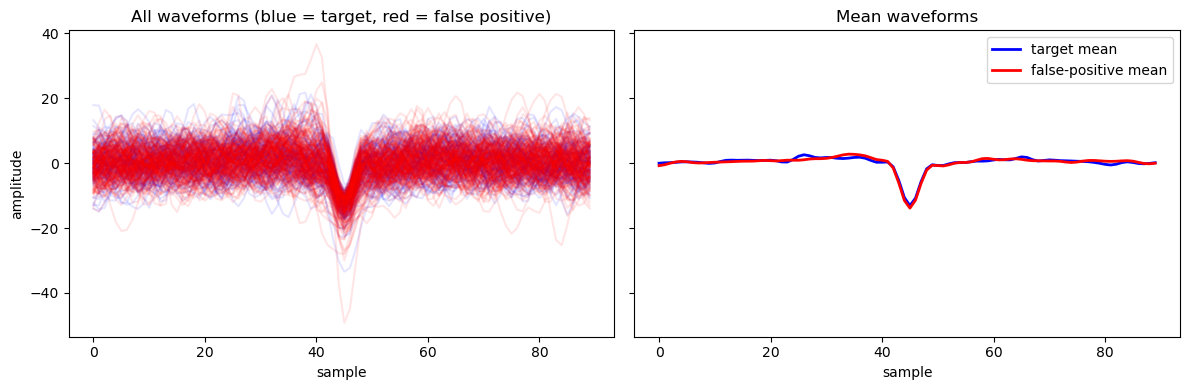

In [192]:
# Overlap between target spikes and false positive spikes
# raw baseline survivors and their labels
survivors = tight_detections_by_signal["raw"] #the 329 detection times
labels = is_target_raw # True = target, False = false positive

# cut each waveform for each survivor from the raw signal
target_waveforms = []
fp_waveforms = []
for survivor_time, is_target in zip(survivors, labels):
    waveform = extract_aligned_waveform(survivor_time, ch19) # cut the wavefom around the survivor
    if waveform is not None:
        if is_target:
            target_waveforms.append(waveform #target group
        else:
            fp_waveforms.append(waveform) # false positive group

target_waveforms = np.array(target_waveforms)
fp_waveforms = np.array(fp_waveforms)

print(f"target waveforms: {len(target_waveforms)}")
print(f"false-positive waveforms: {len(fp_waveforms)}")

#overlay targets (blue) and false positives (red), plus their means
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

#left panel: all waveforms
for waveform in target_waveforms:
    axes[0].plot(waveform, color='blue', alpha=0.1)
for wf in fp_waveforms:
    axes[0].plot(wf, color='red', alpha=0.1)
axes[0].set_title('All waveforms (blue = target, red = false positive)')
axes[0].set_xlabel('sample')
axes[0].set_ylabel('amplitude')

# right panel: the mean waveforms
axes[1].plot(target_waveforms.mean(axis=0), color='blue', linewidth=2, label='target mean')
axes[1].plot(fp_waveforms.mean(axis=0), color='red', linewidth=2, label='false-positive mean')
axes[1].set_title('Mean waveforms')
axes[1].set_xlabel('sample')
axes[1].legend()

plt.tight_layout()
plt.savefig('C:/spike-denoising-synthetic/results/overlap_between_spikes.png', dpi=150)
plt.show()

In [194]:
#denosiing quality: MAD noise level for raw and each denoiser
print(f"{'signal':10s} {'MAD':>8s}")
for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]:
    mad = np.median(np.abs(signal)) / 0.6745
    print(f"{name:10s} {mad:8.3f}")

signal          MAD
raw           4.958
wavelet       2.253
dense         0.559
conv          0.968


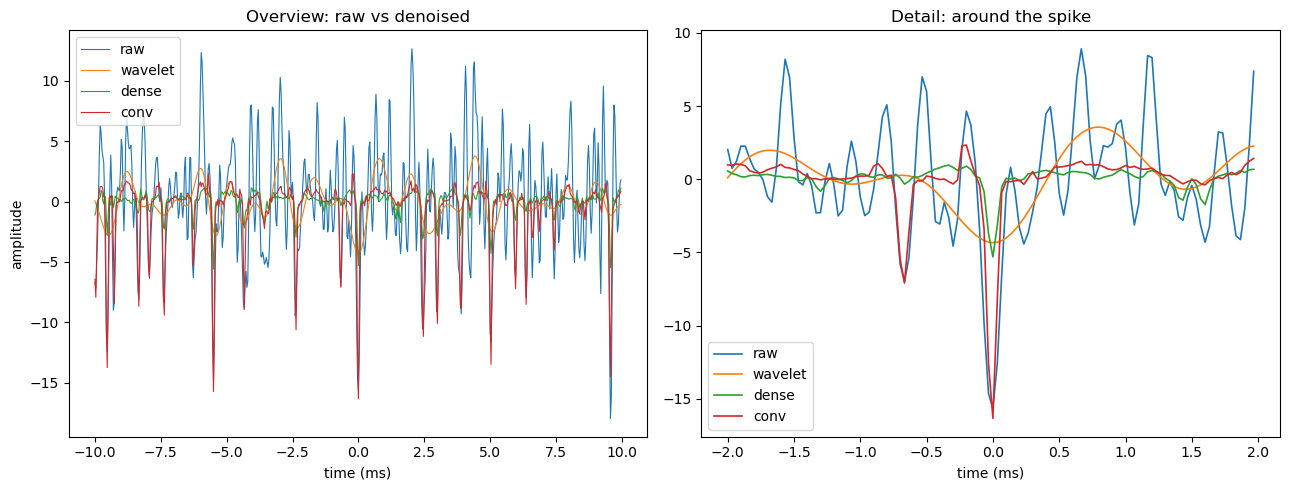

In [204]:
# segment around a target spike similar to how Kechirs's paper presents

example_spike_time = ground_truth_in_window[10]
#search +/- 30 samples around the marked time and find the deepest point
marked_position = int((example_spike_time - window_start) * sample_frequency)
align_window = 30
centre = np.argmin(ch19[marked_position-align_window:marked_position+align_window]) + (marked_position-align_window) #
# overview: wider segment; zoom narrow around the spike
over_half = 300# overview: ~10 ms each side
zoom_half = 60 #zoom: ~2 ms each side

signals = [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left shows overview (all four methods overlaid)
lo, hi = centre - over_half, centre + over_half
t_over = (np.arange(hi - lo) - over_half) / sample_frequency * 1000
for name, sig in signals:
    axes[0].plot(t_over, sig[lo:hi], linewidth=0.8, label=name)
axes[0].set_title("Overview: raw vs denoised")
axes[0].set_xlabel("time (ms)")
axes[0].set_ylabel("amplitude")
axes[0].legend()

#right zoom on the spike
lo, hi = centre - zoom_half, centre + zoom_half
t_zoom = (np.arange(hi - lo) - zoom_half) / sample_frequency * 1000
for name, sig in signals:
    axes[1].plot(t_zoom, sig[lo:hi], linewidth=1.2, label=name)
axes[1].set_title("Detail: around the spike")
axes[1].set_xlabel("time (ms)")
axes[1].legend()
plt.savefig('C:/spike-denoising-synthetic/results/denoising_quality.png', dpi=150)
plt.tight_layout()
plt.show()

In [210]:
# peak-to-peak amplitude
peak_to_peak = {} 
for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet), ("dense", ch19_dense), ("conv", ch19_conv)]:
    amplitude = []
    for spike_time in ground_truth_in_window:
        centre_index = int((spike_time - window_start) * sample_frequency)
        segment = signal[centre_index-45:centre_index+45]
        if len(segment) == 90:
            amplitude.append(segment.max() - segment.min()) #peak to peaak aplitude
    peak_to_peak[name] = np.mean(amplitude)
for name in ["raw", "wavelet", "dense", "conv"]:
    retained = peak_to_peak[name] / peak_to_peak["raw"] * 100
    print(f"{name}: mean peak-to-peak {peak_to_peak[name]:.2f}, retained {retained:.0f}%")

raw: mean peak-to-peak 23.92, retained 100%
wavelet: mean peak-to-peak 7.59, retained 32%
dense: mean peak-to-peak 4.40, retained 18%
conv: mean peak-to-peak 13.00, retained 54%


In [212]:
#full metrics for all four signals for detection after denoising
print(f"{'signal':8s} {'survivors':>5s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'Precision':>6s} {'recall':>6s} {'F1':>6s} {'FP/TP':>6s}")
for name in ["raw", "wavelet", "dense", "conv"]:
    survivors = tight_detections_by_signal[name]
    tp, fp, fn, precision, recall, f1, fptp = score_detections_counts(survivors, ground_truth_in_window, tolerance=0.002)
    print(f"{name:8s} {len(survivors):>5d} {tp:>4d} {fp:>4d} {fn:>4d} {precision:>6.3f} {recall:>7.3f} {f1:>6.3f} {fptp:>6.2f}")
    

signal   survivors   TP   FP   FN Precision recall     F1  FP/TP
raw        329  110  219   67  0.334   0.621  0.435   1.99
wavelet    331  110  221   67  0.332   0.621  0.433   2.01
dense      343  110  233   67  0.321   0.621  0.423   2.12
conv       343  109  234   68  0.318   0.616  0.419   2.15


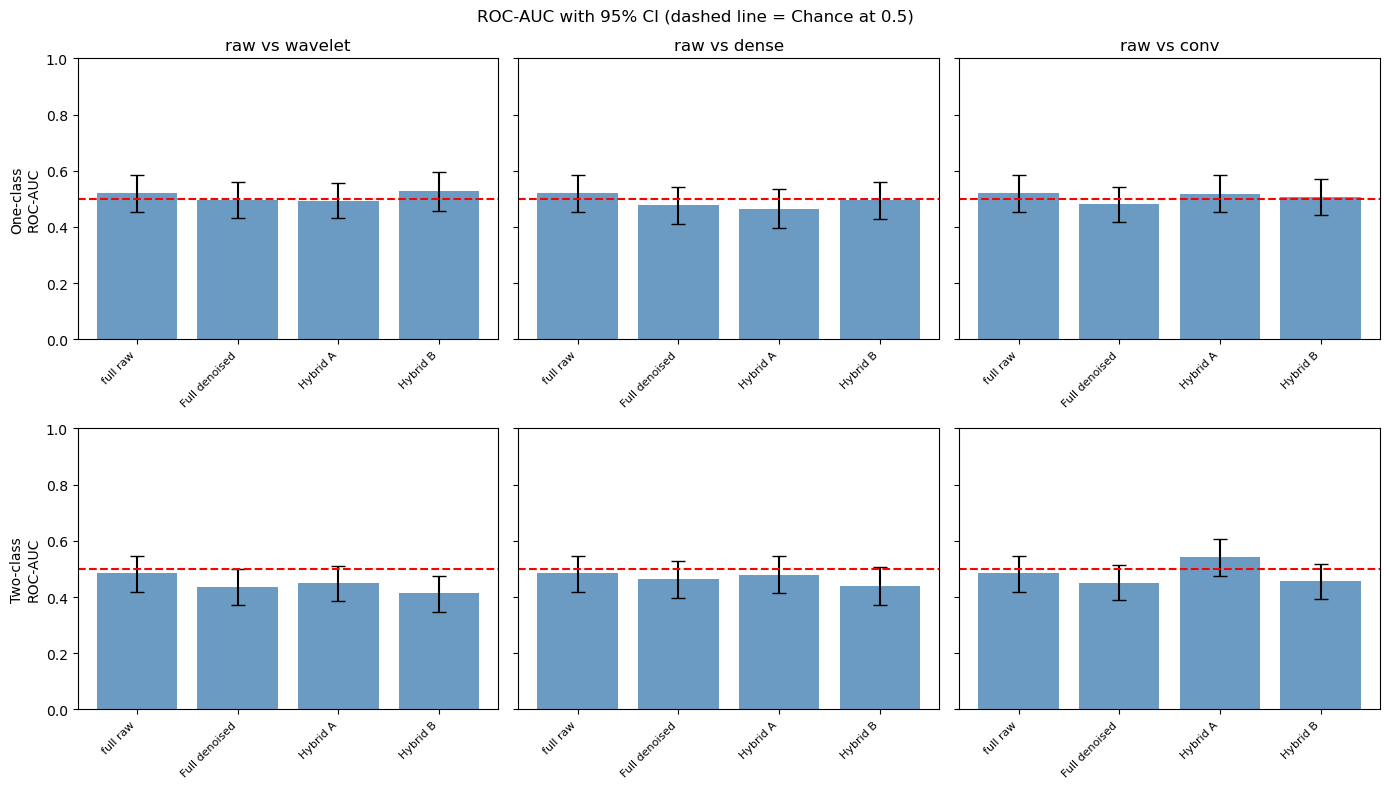

In [256]:
#Generate bar plots similar to Troglio's one class 
denoisers = ["wavelet", "dense", "conv"]
def get_roc_cis(run_helper, denoiser):
    results = [] 
    for label, survivors, is_target, cutout, detail in make_combinations(denoiser):
        *_, arrays = run_helper(survivors, is_target, cutout)
        labels, scores, preds = arrays
        ci = bootstrap_confidence_interval(labels, scores, preds)
        point, lo, hi = ci["roc_auc"]
        results.append((label, point, lo, hi))
    return results
#make a 2 row figure so teh top raw is one class and bottom is two class
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
for row, (classifier_name, run_helper) in enumerate([("One-class", run_oneclass_svm), ("Two-class", run_twoclass_svm)]):
    for column, denoiser in enumerate(denoisers):
        ax = axes[row, column]
        results = get_roc_cis(run_helper, denoiser)
        labels = [r[0] for r in results]
        points = [r[1] for r in results]
        los = [r[1]-r[2] for r in results]
        his = [r[3]-r[1] for r in results]
        x = np.arange(len(labels))
        ax.bar(x, points, yerr=[los, his], capsize=5, color='steelblue', alpha=0.8)
        ax.axhline(0.5, color='red', linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        if row == 0:
            ax.set_title(f"raw vs {denoiser}")
        if column == 0:
            ax.set_ylabel(f"{classifier_name}\nROC-AUC")
plt.suptitle("ROC-AUC with 95% CI (dashed line = Chance at 0.5)")
plt.tight_layout()
plt.show()
        
        

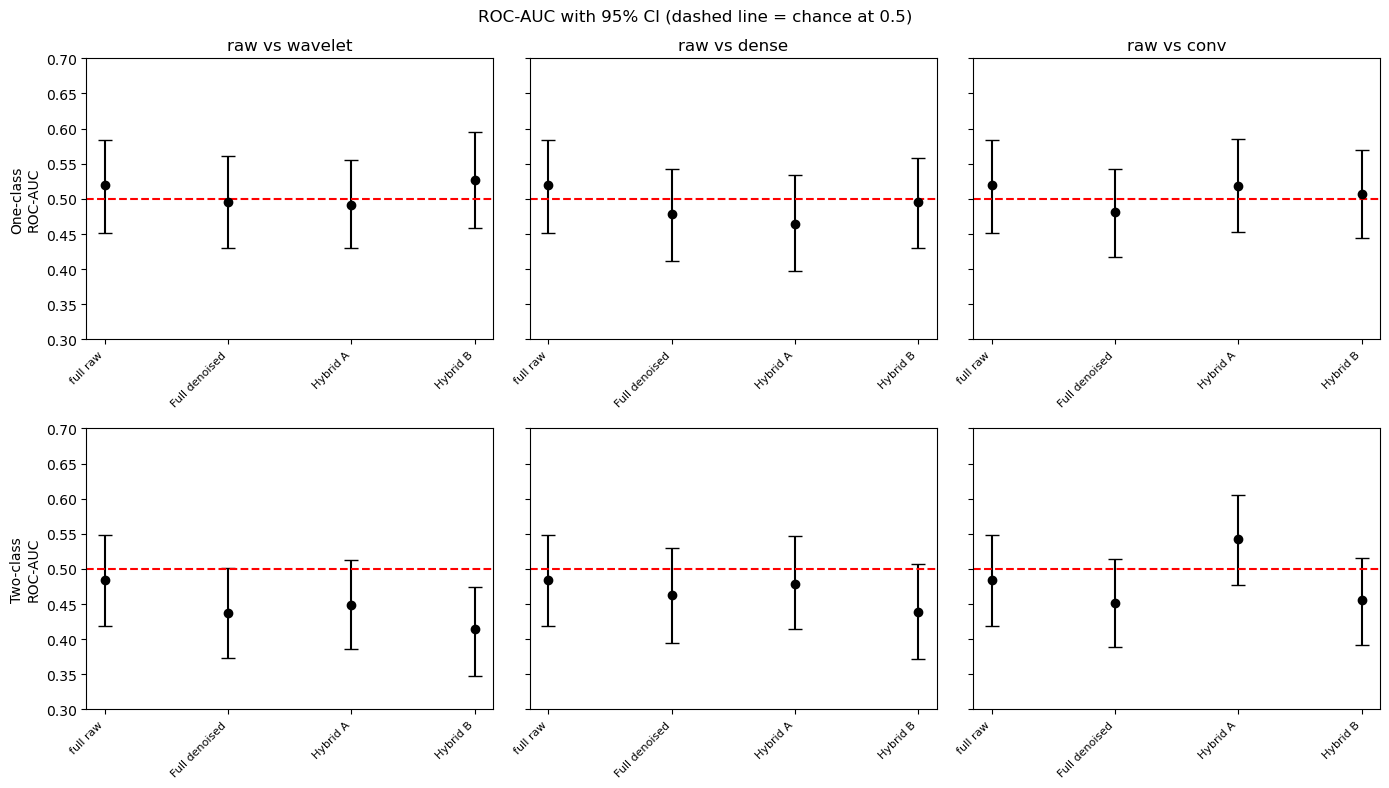

In [258]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
for row, (classifier_name, run_helper) in enumerate([("One-class", run_oneclass_svm), ("Two-class", run_twoclass_svm)]):
    for column, denoiser in enumerate(denoisers):
        ax = axes[row, column]
        results = get_roc_cis(run_helper, denoiser)
        labels = [r[0] for r in results]
        points = [r[1] for r in results]
        los = [r[1]-r[2] for r in results]
        his = [r[3]-r[1] for r in results]
        x = np.arange(len(labels))
        
        ax.errorbar(x, points, yerr=[los, his], fmt='o', capsize=5, color='black', markersize=6)
        ax.axhline(0.5, color='red', linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0.3, 0.7) 
        if row == 0:
            ax.set_title(f"raw vs {denoiser}")
        if column == 0:
            ax.set_ylabel(f"{classifier_name}\nROC-AUC")
plt.suptitle("ROC-AUC with 95% CI (dashed line = chance at 0.5)")
plt.tight_layout()
plt.savefig('C:/spike-denoising-synthetic/results/ROC-AUC.png', dpi=150)
plt.show()

# Lekasge safe evaluation
Above, I used the same 900 s window to construct templates. Here, I'm gonna attempt a chronological development/evaluation split.  
Development data selects the latency/shaper parameters and supplies the target template for denoiser training and template matching; the held-out evaluation period is scored once. Because the denoiser is trained on a synthetic target template, the template must also come only from development data. 

In [263]:
print(f"window_start: {window_start}")
print(f"total samples: {len(ch19)}")
print(f"sample_frequency: {sample_frequency}")
window_end = window_start + len(ch19) / sample_frequency
print(f"window_end (computed): {window_end}")

window_start: 3602.6708
total samples: 27000000
sample_frequency: 30000
window_end (computed): 4502.6708


In [272]:

print("ch19 shape:", ch19.shape)
print("ch19 first few values:", ch19[:5])

# The TTLs, how many, and their range
print("\nTTLs: count", len(ttls))
print("TTL range:", ttls.min(), "to", ttls.max())
print("Window:", window_start, "to", window_end)

# ground truth
print("\nground_truth_in_window: count", len(ground_truth_in_window))
print("GT range:", ground_truth_in_window.min(), "to", ground_truth_in_window.max())

ch19 shape: (27000000,)
ch19 first few values: [ 5.18257143  5.67971554  4.16198509  1.59263826 -2.21483572]

TTLs: count 2310
TTL range: 2.0357 to 8269.148766666667
Window: 3602.6708 to 4502.6708

ground_truth_in_window: count 177
GT range: 3602.7732333333333 to 4499.627733333334


In [273]:

ttls_in_window = ttls[(ttls >= window_start) & (ttls <= window_end)]
print("TTLs in window:", len(ttls_in_window))
print("First few in-window TTLs:", ttls_in_window[:5])
print("Spacing of first few:", np.diff(ttls_in_window[:10]))


TTLs in window: 189
First few in-window TTLs: [3602.6708 3606.6715 3610.6722 3614.6729 3618.6736]
Spacing of first few: [4.0007     4.0007     4.0007     4.0007     4.0007     4.00073333
 4.0007     4.0007     4.0007    ]


In [271]:
# Sets 30% of the recording aside for evaluation to prevent data leakage. 
# The other 70% is for development
EVAL_FRACTION = 0.30
#the time that divides development from evaluation
split_time = window_start + (window_end - window_start) * (1 - EVAL_FRACTION) #so the time point at 70% through the recoding (~4232.67). before it= development; after it = evaluation
# The target spikes in development period; this is to keep only ground truth spikes whose time is before the split (so in the first 70%)
ground_truth_dev = ground_truth_in_window[ground_truth_in_window < split_time]
#the target spikes in the evaluation period, so only keeps ground truth spikes at or after the split, so the last 30%
ground_truth_eval = ground_truth_in_window[ground_truth_in_window >= split_time]
ttls_dev = ttls[(ttls >= window_start) & (ttls < split_time)] # the stimulus time in the development period so before the split
ttls_eval = ttls[(ttls >= split_time) & (ttls <= window_end)] # the stimulus time in the evaluation period at or after the split
print(f"split_time: {split_time:.3f} s")
print(f"Development interval: {window_start:.3f}-{split_time:.3f} s ({split_time-window_start:.0f} s); targets: {len(ground_truth_dev)}")
print(f"Evaluation interval: {split_time:.3f}-{window_end:.3f} s ({window_end-split_time:.0f} s) : targets: {len(ground_truth_eval)}")
print(f"total targets: {len(ground_truth_dev) + len(ground_truth_eval)}")
print(f"dev TTLs: {len(ttls_dev)}, eval TTLs: {len(ttls_eval)}")

split_time: 4232.671 s
Development interval: 3602.671-4232.671 s (630 s); targets: 116
Evaluation interval: 4232.671-4502.671 s (270 s) : targets: 61
total targets: 177
dev TTLs: 121, eval TTLs: 68


In [305]:
#build the template from the development only 
#take the manually marked spike times, cut out each spike's waveform and average them to get the template
#cut the final 90-sample waveforms centred on the trough
#average all the waveforms = the template 
def build_template_from_annotations(signal, spike_times, reference_start=window_start, half_width=45, align_window=30):
    """
    Build a template by averaging aligned waveforms from the given spike times (dev only)
    """
    segments = []
    for spike_time in spike_times:
        centre_index = int(round((spike_time - reference_start) * sample_frequency)) #convert the spiek time seconds to sample postion 
        # define wide window around the spike so wider than the final template to have room to find the trough. 
        lo = centre_index - half_width - align_window
        hi = centre_index + half_width + align_window
        if lo < 0 or hi > len(signal): #skip spikes too close to the signal's edge (where it can't cut a full window)
            continue
        wide = signal[lo:hi] #cut the wide wavefroms 
        #find the trough near the centre of the wide window
        centre = half_width + align_window #the middle of the wide window
        local = wide[centre-align_window:centre+align_window] #a small region aroud the centre
        trough_index = np.argmin(local) + (centre-align_window) #the position of the deepest point in that region and convert back to the wide window's index
        #cut the final wavefoms (90 samples) centres on the trough
        segment = wide[trough_index-half_width:trough_index+half_width]
        if len(segment) == 2 * half_width: # only keep full length waveforms so 90 samples and add them to a list
           #raise an error if no valid waveforms were found
            segments.append(segment)
        if not segments:
            raise ValueError("No complete annotated waveforms available to build the development template.")
        return np.mean(np.asarray(segments), axis=0) #average all the waveforms across the list to get the template. 
#build the raw template from development spikes only 
raw_template_dev = build_template_from_annotations(ch19, ground_truth_dev)
print("Development only raw template length:", len(raw_template_dev))
print("development template trough", raw_template_dev.min())
print("(build from", len(ground_truth_dev), "development target spikes)")

#compute latency statistics from development annotation only
def post_stimulus_latencies(spike_times, stimuli):
    """
    latency of each spike relative to the preceding stimulus in ms
    """
    index = np.searchsorted(stimuli, spike_times, side='right') -1
    valid = index >= 0
    return (spike_times[valid] - stimuli[index[valid]]) * 1000
latency_dev = post_stimulus_latencies(ground_truth_dev, ttls_dev)
median_latency_dev = float(np.median(latency_dev))
print(f"Development median latency: {median_latency_dev:.3f} ms")
print(f"(from {len(latency_dev)} development spikes)")

Development only raw template length: 90
development template trough -14.095593440067038
(build from 116 development target spikes)
Development median latency: 100.133 ms
(from 116 development spikes)


In [289]:

noisy_windows_dev, clean_windows_dev = make_training_pairs_real(raw_template_dev)
print("dev training pairs:", noisy_window_dev.shape, clean_windows_dev.shape)

dev training pairs: torch.Size([40000, 60]) torch.Size([40000, 60])


In [291]:
#retrain the dense autoencoder with the dev template
torch.manual_seed(0)
dense_denoiser_dev = DenseDAE(window=60, hidden=15)
optimiser = torch.optim.Adam(dense_denoiser_dev.parameters(), lr=1e-3)
mse_loss = nn.MSELoss()
training_data = torch.utils.data.TensorDataset(noisy_windows_dev, clean_windows_dev)
batches = torch.utils.data.DataLoader(training_data, batch_size=256, shuffle=True)
for epoch in range(30):
    epoch_loss = 0
    for noisy_batch, clean_batch in batches:
        optimiser.zero_grad()
        loss = mse_loss(dense_denoiser_dev(noisy_batch), clean_batch)
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
    if epoch % 10 == 0 or epoch == 29:
        print(f"epoch {epoch:2d} loss {epoch_loss/len(batches):.4f}")

epoch  0 loss 0.1555
epoch 10 loss 0.0037
epoch 20 loss 0.0028
epoch 29 loss 0.0024


In [293]:
#retarin conv 
torch.manual_seed(0)
conv_denoiser_dev = ConvDAE()
noisy_conv_dev = noisy_windows_dev.unsqueeze(1)
clean_conv_dev = clean_windows_dev.unsqueeze(1)

optimiser = torch.optim.Adam(conv_denoiser_dev.parameters(), lr=1e-3)
mse_loss = nn.MSELoss()
training_data = torch.utils.data.TensorDataset(noisy_windows_dev, clean_windows_dev)
batches = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(noisy_conv_dev, clean_conv_dev), batch_size=256, shuffle=True)
for epoch in range(30):
    epoch_loss = 0
    for noisy_batch, clean_batch in batches:
        optimiser.zero_grad()
        loss = mse_loss(conv_denoiser_dev(noisy_batch), clean_batch)
        loss.backward()
        optimiser.step()
        epoch_loss += loss.item()
    if epoch % 10 == 0 or epoch == 29:
        print(f"epoch {epoch:2d} loss {epoch_loss/len(batches):.4f}")

epoch  0 loss 0.0932
epoch 10 loss 0.0294
epoch 20 loss 0.0261
epoch 29 loss 0.0246


In [300]:
ch19_wavelet_dev = denoise_swt_channel(ch19)
#apply the leakage free denoisers to the full signal
ch19_dense_dev = ae_denoise_signal(ch19, dense_denoiser_dev)
ch19_conv_dev = conv_ae_denoise(ch19, conv_denoiser_dev)
print("\nshapes:", ch19_wavelet_dev.shape, ch19_dense_dev.shape, ch19_conv_dev.shape)


shapes: (27000000,) (27000000,) (27000000,)


In [303]:
#Build templates from DEV spikes only, for each signal.
templates_dev = {}
signals_dev = {"raw": ch19, "wavelet": ch19_wavelet_dev, "dense": ch19_dense_dev, "conv": ch19_conv_dev}
for name, signal in signals_dev.items():
    templates_dev[name] = build_template_from_annotations(signal, ground_truth_dev)
    print(f"{name}: template trough {templates_dev[name].min():.2f}")

raw: template trough -14.10
wavelet: template trough -1.78
dense: template trough -2.87
conv: template trough -8.01


In [312]:
#detect on the raw signal, restrict to the dev period, score against dev spikes
template_dev_raw = templates_dev["raw"] #dev template for raw
scores = template_match(ch19, template_dev_raw)

# sweep shape threshold and letency hald-width on dev
print(f"{'shape_th':>8s} {'lat_hlaf_width':>6s} {'kept_dev':>8s} {'precision':>6s} {'recall':>7s} {'F1':>6s}")
best_f1, best_params = 0, None
for shape_th in [0.2, 0.3, 0.4, 0.5]:
    for lat_half_width in [2, 3, 4, 5, 6]: #latency hald width in ms
        peaks, _ = find_peaks(scores, height=shape_th, distance=90)
        detections = peaks / sample_frequency + window_start
        lo = (median_latency_dev - lat_half_width) / 1000
        hi = (median_latency_dev + lat_half_width) / 1000
        in_window = detections[in_latency_window(detections, ttls, lat_min=lo, lat_max=hi)]
        #restricst to dev period only
        dev_detections = in_window[in_window < split_time]
        tp, fp, fn, precision, recall, f1, fptp = score_detections_counts(dev_detections, ground_truth_dev, tolerance=0.002)
        if f1 > best_f1:
            best_f1, best_params = f1, (shape_th, lat_half_width)
        print(f"{shape_th:>8.1f} {lat_half_width:>6d} {len(dev_detections):>8d} {precision:>6.3f} {recall:>7.3f} {f1:>6.3f}")
print(f"\nBest on dev: shape_threshold={best_params[0]}, latency_half_width={best_params[1]} ms (F1={best_f1:.3f})")      

shape_th lat_hlaf_width kept_dev precision  recall     F1
     0.2      2      114  0.553   0.543  0.548
     0.2      3      168  0.440   0.638  0.521
     0.2      4      212  0.377   0.690  0.488
     0.2      5      273  0.319   0.750  0.447
     0.2      6      337  0.291   0.845  0.433
     0.3      2      103  0.544   0.483  0.511
     0.3      3      152  0.434   0.569  0.493
     0.3      4      190  0.379   0.621  0.471
     0.3      5      244  0.320   0.672  0.433
     0.3      6      306  0.291   0.767  0.422
     0.4      2       55  0.473   0.224  0.304
     0.4      3       86  0.372   0.276  0.317
     0.4      4      106  0.330   0.302  0.315
     0.4      5      132  0.273   0.310  0.290
     0.4      6      168  0.256   0.371  0.303
     0.5      2       11  0.455   0.043  0.079
     0.5      3       17  0.412   0.060  0.105
     0.5      4       21  0.381   0.069  0.117
     0.5      5       28  0.321   0.078  0.125
     0.5      6       34  0.265   0.078  0.120

B

In [316]:
#
final_shape_th = best_params[0] #so 0.2
final_latency_half_width = best_params[1] #2ms
print(f"selected parameters on dev:shape_threshold={final_shape_th}, latency_half_width={final_latency_half_width} ms")

selected parameters on dev:shape_threshold=0.2, latency_half_width=2 ms


In [319]:
#now apply the selected parameters to the evaluation period and score once
final_shape_th = best_params[0] #so 0.2
final_latency_half_width = best_params[1] #2ms
lo_eval = (median_latency_dev - final_latency_half_width) / 1000
hi_eval = (median_latency_dev + final_latency_half_width) / 1000

signals_dev = {"raw": ch19, "wavelet":ch19_wavelet_dev, "dense":ch19_dense_dev, "conv": ch19_conv_dev}
eval_detections_by_signal ={}
print(f"{'signal':8s} {'kept_eval':>9s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'precision':>6s} {'recall':>7s} {'F1':>6s} {'FP/TP':>6s}")
for name, signal in signals_dev.items():
    template = templates_dev[name] #dev template for this signal
    scores = template_match(signal, template)
    peaks, _ = find_peaks(scores, height=final_shape_th, distance=90)
    detections = peaks / sample_frequency + window_start
    in_window = detections[in_latency_window(detections, ttls, lat_min=lo_eval, lat_max=hi_eval)]
    # restrict to eval period only
    eval_detections = in_window[in_window >= split_time]
    eval_detections_by_signal[name] = eval_detections
    tp, fp, fn, precision, recall, f1, fptp = score_detections_counts(eval_detections, ground_truth_eval, tolerance=0.002)
    
    print(f"{name:8s} {len(eval_detections):>9d} {tp:>4d} {fp:>4d} {fn:>4d} {precision:>6.3f} {recall:>7.3f} {f1:>6.3f} {fptp:>6.2f}")

signal   kept_eval   TP   FP   FN precision  recall     F1  FP/TP
raw             68   18   50   43  0.265   0.295  0.279   2.78
wavelet         52   20   32   41  0.385   0.328  0.354   1.60
dense           63   14   49   47  0.222   0.230  0.226   3.50
conv            64   21   43   40  0.328   0.344  0.336   2.05


In [321]:
# generate dev survivors restricted to dev period for training the classifier
dev_detections_by_signal = {}
for name, signal in signals_dev.items():
    template = templates_dev[name]
    scores = template_match(signal, template)
    peaks, _ = find_peaks(scores, height=final_shape_th, distance=90)
    detections = peaks / sample_frequency + window_start
    in_window = detections[in_latency_window(detections, ttls, lat_min=lo_eval, lat_max=hi_eval)]
    dev_detections = in_window[in_window < split_time] #restrics to dev
    dev_detections_by_signal[name] = dev_detections
    print(f"{name}: {len(dev_detections)} dev survivors")

raw: 114 dev survivors
wavelet: 113 dev survivors
dense: 114 dev survivors
conv: 113 dev survivors


In [351]:
#label dev and eval survivors (target vs non-target)
def label_survivors(survivor_times, annotations, tolerance=0.002):
    """
    label each survivor as target (ture) if withing tolerance of an annotation, else is non target (false)
    """
    return np. array([np.any(np.abs(annotations - t) <= tolerance) for t in survivor_times])

# label dev and eval survivors for each signal
dev_labels_by_signal = {}
eval_labels_by_signal = {}
for  name in signals_dev:
    dev_labels_by_signal[name] = label_survivors(dev_detections_by_signal[name], ground_truth_dev)
    eval_labels_by_signal[name] = label_survivors(eval_detections_by_signal[name], ground_truth_eval)
    print(f"{name}: dev {dev_labels_by_signal[name].sum()} targets / {len(dev_labels_by_signal[name])} survivors; "
          f"eval {eval_labels_by_signal[name].sum()} targets / {len(eval_labels_by_signal[name])} survivors")

def extract_waveforms(survivor_times, signal, half_width=45, align_window=30):
    """
    Extract aligned waveforms for the given survivor times from the signal
    """
    waveforms = []
    keep = []
    for t in survivor_times:
        centre_index = int(round((t - window_start) * sample_frequency))
        lo, hi = centre_index - half_width - align_window, centre_index + half_width + align_window
        if lo < 0 or hi > len(signal):
            keep.append(False)
            continue
        wide = signal[lo:hi]
        centre = half_width + align_window
        trough = np.argmin(wide[centre-align_window:centre+align_window]) + (centre-align_window)
        segment = wide[trough-half_width:trough+half_width]
        if len(segment) == 2*half_width:
            waveforms.append(segment)
            keep.append(True)
        else:
            keep.append(False)
    return np.array(waveforms), np.array(keep)

def oneclass_dev_eval(dev_waveforms, dev_labels, eval_waveforms, eval_labels, nu=0.1):
    """
    One-class SVM: train on DEV target waveforms, score EVAL waveforms
    """
    dev_targets = dev_waveforms[dev_labels]#train on dev targets only
    svm = OneClassSVM(kernel="rbf", gamma="scale", nu=nu).fit(dev_targets)
    eval_scores = svm.decision_function(eval_waveforms)#score eval
    eval_preds = (eval_scores > 0).astype(int)
    return eval_labels.astype(int), eval_scores, eval_preds
def twoclass_dev_eval(dev_waveforms, dev_labels, eval_waveforms, eval_labels, C=1.0):
    """
    Two-class SVM: train on DEV (both classes), score EVAL. Scaler fit on dev only
    """
    scaler = StandardScaler().fit(dev_waveforms)#fit scaler on DEV only
    svm = SVC(kernel="rbf", C=C, gamma="scale", class_weight="balanced")
    svm.fit(scaler.transform(dev_waveforms), dev_labels.astype(int))
    eval_scores = svm.decision_function(scaler.transform(eval_waveforms))
    eval_preds = svm.predict(scaler.transform(eval_waveforms))
    return eval_labels.astype(int), eval_scores, eval_preds
def bootstrap_ci_stratified(labels, scores, preds=None, n_boot=2000, seed=0, alpha=0.05):
    """
    Stratified percentile bootstrap: resample within each class to preserve the balance.
    """
    labels = np.asarray(labels); scores = np.asarray(scores)
    preds = (scores > 0).astype(int) if preds is None else np.asarray(preds)
    target_index = np.where(labels == 1)[0]
    nontarget_index = np.where(labels == 0)[0]
    rng = np.random.default_rng(seed)
    keys = ["precision", "recall", "f1", "roc_auc", "pr_ap"]
    bootstrap_values = {metric_name: [] for metric_name in keys}

    for _ in range(n_boot):
        target_resample = rng.choice(target_index, len(target_index), replace=True)
        nontarget_resample = rng.choice(nontarget_index, len(nontarget_index), replace=True)
        index = np.concatenate([target_resample, nontarget_resample])
        if len(np.unique(labels[index])) < 2:
            continue
        metrics_this_resample = _metrics(labels[index], preds[index], scores[index])
        for metric_name in keys:
            bootstrap_values[metric_name].append(metrics_this_resample[metric_name])

    point = _metrics(labels, preds, scores)
    out = {}
    for metric_name in keys:
        array = np.asarray(bootstrap_values[metric_name], dtype=float)
        lo, hi = np.percentile(array, [100*alpha/2, 100*(1-alpha/2)])
        out[metric_name] = (point[metric_name], float(lo), float(hi))
    return out
        
def run_arm_dev_eval(detection, cutout, classifier, n_boot=2000, seed=0):
    """
    One 2x2 arm with no data leakage: dev survivors from the detection signal; waveforms cut from the cutout signal.
    Train on dev, score on eval once, bootstrap CIs.
    """
    # dev and eval survivorss from detection signal
    dev_surv = dev_detections_by_signal[detection]
    eval_surv = eval_detections_by_signal[detection]
    dev_labels_all = dev_labels_by_signal[detection]
    eval_labels_all = eval_labels_by_signal[detection]
    cutout_signal = signals_dev[cutout]
    #extract wavefroms from the cutout signal
    dev_waveforms, dev_keep = extract_waveforms(dev_surv, cutout_signal)
    eval_waveforms, eval_keep = extract_waveforms(eval_surv, cutout_signal)
    dev_labels = dev_labels_all[dev_keep]
    eval_labels = eval_labels_all[eval_keep]
    #fit on dev and score on eval
    if classifier == "oneclass":
        labels, scores, preds = oneclass_dev_eval(dev_waveforms, dev_labels, eval_waveforms, eval_labels)
    else:
        labels, scores, preds = twoclass_dev_eval(dev_waveforms, dev_labels, eval_waveforms, eval_labels)

    #point metrics + bootstrap CI on the eval candidates
    ci = bootstrap_ci_stratified(labels, scores, preds, n_boot=n_boot, seed=seed)
    return ci, eval_labels.mean() #ci dict + base rate
def make_arms(denoiser):
    return[
        ("Full raw", "raw", "raw"),
        ("Full denoised", denoiser, denoiser),
        ("Hybrid A", denoiser, "raw"),
        ("Hybrid B", "raw", denoiser),
    ]
for classifier in ["oneclass", "twoclass"]:
    print(f"\n==={classifier.upper()} (no leakage, eval)===")
    for denoiser in ["wavelet", "dense", "conv"]:
        print(f"\n--raw vs {denoiser}--")
        print(f"{'arm':14s} {'Roc-AUC [95% CI]':>24s} {'PR-AP [95% CI':>22s} {'base':>6s}")
        for label, det, cut in make_arms(denoiser):
            ci, base = run_arm_dev_eval(det, cut, classifier)
            roc = ci["roc_auc"]; prap = ci["pr_ap"]
            print(f"{label:14s} {roc[0]:.3f} [{roc[1]:.3f},{roc[2]:.3f}]".rjust(24) +
                  f"  {prap[0]:.3f} [{prap[1]:.3f},{prap[2]:.3f}]".rjust(22) +
                  f"  {base:.3f}")

raw: dev 65 targets / 114 survivors; eval 19 targets / 68 survivors
wavelet: dev 64 targets / 113 survivors; eval 20 targets / 52 survivors
dense: dev 60 targets / 114 survivors; eval 14 targets / 63 survivors
conv: dev 63 targets / 113 survivors; eval 22 targets / 64 survivors

===ONECLASS (no leakage, eval)===

--raw vs wavelet--
arm                    Roc-AUC [95% CI]          PR-AP [95% CI   base
Full raw       0.403 [0.249,0.564]   0.296 [0.214,0.491]  0.279
Full denoised  0.430 [0.273,0.595]   0.352 [0.299,0.513]  0.385
Hybrid A       0.512 [0.345,0.669]   0.401 [0.327,0.585]  0.385
Hybrid B       0.294 [0.163,0.443]   0.251 [0.189,0.379]  0.279

--raw vs dense--
arm                    Roc-AUC [95% CI]          PR-AP [95% CI   base
Full raw       0.403 [0.249,0.564]   0.296 [0.214,0.491]  0.279
Full denoised  0.599 [0.433,0.765]   0.307 [0.220,0.528]  0.222
Hybrid A       0.468 [0.273,0.649]   0.248 [0.176,0.443]  0.222
Hybrid B       0.473 [0.313,0.641]   0.306 [0.232,0.502]  0.

In [352]:
print("signals_dev keys and whether they're the dev signals:")
for name in signals_dev:
    sigment = signals_dev[name]
    print(f"  {name}: id matches...")
# Check if signals_dev["dense"] is the dev signal
print("signals_dev['dense'] is ch19_dense_dev:", signals_dev["dense"] is ch19_dense_dev)
print("signals_dev['conv'] is ch19_conv_dev:", signals_dev["conv"] is ch19_conv_dev)
print("signals_dev['wavelet'] is ch19_wavelet_dev:", "ch19_wavelet_dev" in dir() and signals_dev["wavelet"] is ch19_wavelet_dev)

signals_dev keys and whether they're the dev signals:
  raw: id matches...
  wavelet: id matches...
  dense: id matches...
  conv: id matches...
signals_dev['dense'] is ch19_dense_dev: True
signals_dev['conv'] is ch19_conv_dev: True
signals_dev['wavelet'] is ch19_wavelet_dev: True


In [353]:
for name, dev_model in [("dense", dense_denoiser_dev), ("conv", conv_denoiser_dev)]:
    sig = signals_dev[name]
    if name == "dense":
        recheck = ae_denoise_signal(ch19, dev_model)
    else:
        recheck = conv_ae_denoise(ch19, dev_model)
    print(f"{name}: matches dev model? {np.abs(recheck - sig).mean():.6f} (0 = yes)")

dense: matches dev model? 0.000000 (0 = yes)
conv: matches dev model? 0.000000 (0 = yes)


In [342]:
# Try a different split fraction to see if the dense anomaly is split-specific
# (This is a robustness check, not the final analysis)
for frac in [0.30, 0.35, 0.40]:
    st = window_start + (window_end - window_start) * (1 - frac)
    gt_d = ground_truth_in_window[ground_truth_in_window < st]
    gt_e = ground_truth_in_window[ground_truth_in_window >= st]
    print(f"eval fraction {frac}: {len(gt_e)} eval targets")

eval fraction 0.3: 61 eval targets
eval fraction 0.35: 66 eval targets
eval fraction 0.4: 67 eval targets


In [343]:
print("dev/eval target overlap:", len(np.intersect1d(ground_truth_dev, ground_truth_eval)))  # should be 0
print("dev max < eval min:", ground_truth_dev.max() < ground_truth_eval.min())  # should be True

dev/eval target overlap: 0
dev max < eval min: True


In [345]:
for name in signals_dev:
    d = dev_detections_by_signal[name]
    e = eval_detections_by_signal[name]
    dev_ok = len(d) == 0 or d.max() < split_time
    eval_ok = len(e) == 0 or e.min() >= split_time
    print(f"{name}: dev detections before split? {dev_ok}; eval after split? {eval_ok}")

raw: dev detections before split? True; eval after split? True
wavelet: dev detections before split? True; eval after split? True
dense: dev detections before split? True; eval after split? True
conv: dev detections before split? True; eval after split? True


In [346]:
for name in signals_dev:
    recheck = build_template_from_annotations(signals_dev[name], ground_truth_dev)
    print(f"{name}: template dev-only? {np.abs(recheck - templates_dev[name]).mean():.6f}")

raw: template dev-only? 0.000000
wavelet: template dev-only? 0.000000
dense: template dev-only? 0.000000
conv: template dev-only? 0.000000


In [354]:
# Leakage safe detection results (clean, for presentation)
print("=== LEAKAGE-SAFE DETECTION (held-out eval) ===")
print(f"{'signal':8s} {'kept':>5s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'prec':>6s} {'recall':>7s} {'F1':>6s} {'FP/TP':>6s}")
detection_results_eval = {}
for name, signal in signals_dev.items():
    template = templates_dev[name]
    scores = template_match(signal, template)
    peaks, _ = find_peaks(scores, height=final_shape_th, distance=90)
    detections = peaks / sample_frequency + window_start
    in_window = detections[in_latency_window(detections, ttls, lat_min=lo_eval, lat_max=hi_eval)]
    eval_det = in_window[in_window >= split_time]
    tp, fp, fn, precision, recall, f1, fptp = score_detections_counts(eval_det, ground_truth_eval, tolerance=0.002)
    detection_results_eval[name] = (len(eval_det), tp, fp, fn, precision, recall, f1, fptp)
    print(f"{name:8s} {len(eval_det):>5d} {tp:>4d} {fp:>4d} {fn:>4d} {precision:>6.3f} {recall:>7.3f} {f1:>6.3f} {fptp:>6.2f}")

=== LEAKAGE-SAFE DETECTION (held-out eval) ===
signal    kept   TP   FP   FN   prec  recall     F1  FP/TP
raw         68   18   50   43  0.265   0.295  0.279   2.78
wavelet     52   20   32   41  0.385   0.328  0.354   1.60
dense       63   14   49   47  0.222   0.230  0.226   3.50
conv        64   21   43   40  0.328   0.344  0.336   2.05


In [355]:
#Store the leakage safe classification results (for the table)
classification_results_eval = {}
for classifier in ["oneclass", "twoclass"]:
    for denoiser in ["wavelet", "dense", "conv"]:
        for label, det, cut in make_arms(denoiser):
            ci, base = run_arm_dev_eval(det, cut, classifier)
            classification_results_eval[(classifier, denoiser, label)] = {
                "roc_auc": ci["roc_auc"],
                "pr_ap": ci["pr_ap"],
                "f1": ci["f1"],
                "base": base
            }
print("Stored classification results for", len(classification_results_eval), "arms")

Stored classification results for 24 arms


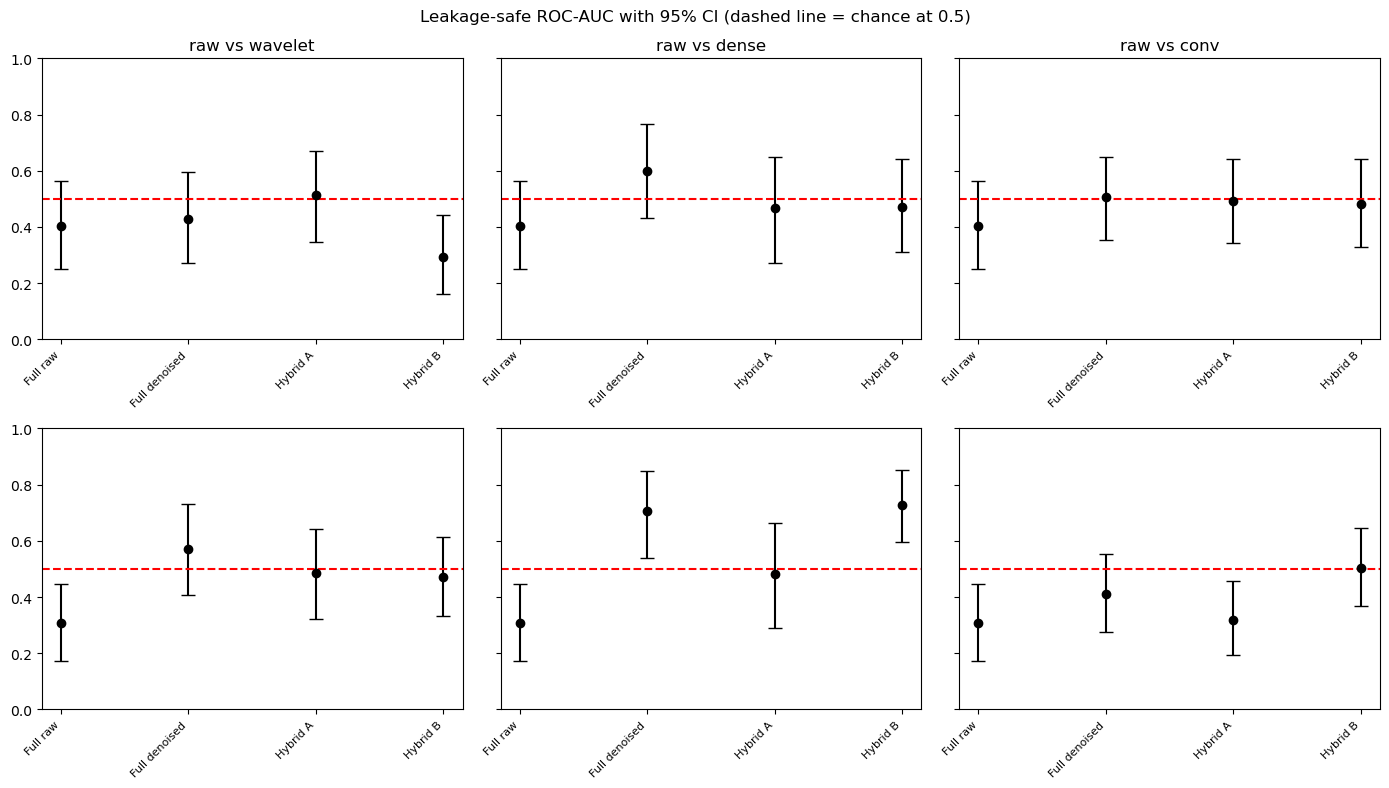

In [357]:
#plot ROC-AUC dot plot like troglio with the leak safe results
denoisers = ["wavelet", "dense", "conv"]
arm_labels = ["Full raw", "Full denoised", "Hybrid A", "Hybrid B"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)

for row, classifier in enumerate(["oneclass", "twoclass"]):
    for column, denoiser in enumerate(denoisers):
        ax = axes[row, column]
        points, los, his = [], [], []
        for label in arm_labels:
            r = classification_results_eval[(classifier, denoiser, label)]["roc_auc"]
            points.append(r[0])
            los.append(r[0] - r[1])
            his.append(r[2] - r[0])
        x = np.arange(len(arm_labels))
        ax.errorbar(x, points, yerr=[los, his], fmt='o', capsize=5, color='black', markersize=6)
        ax.axhline(0.5, color='red', linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels(arm_labels, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        if row == 0:
            ax.set_title(f"raw vs {denoiser}")
        if col == 0:
            ax.set_ylabel(f"{'One-class' if classifier=='oneclass' else 'Two-class'}\nROC-AUC")

plt.suptitle("Leakage-safe ROC-AUC with 95% CI (dashed line = chance at 0.5)")
plt.tight_layout()
plt.show()

In [358]:
# MAD of the leakage safe denoised signals
print(f"{'signal':10s} {'MAD':>8s}")
for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet_dev), ("dense", ch19_dense_dev), ("conv", ch19_conv_dev)]:
    mad = np.median(np.abs(signal)) / 0.6745
    print(f"{name:10s} {mad:8.3f}")

signal          MAD
raw           4.958
wavelet       2.253
dense         0.765
conv          2.885


In [359]:
peak_to_peak = {}
for name, signal in [("raw", ch19), ("wavelet", ch19_wavelet_dev), ("dense", ch19_dense_dev), ("conv", ch19_conv_dev)]:
    amplitude = []
    for spike_time in ground_truth_dev:# use dev spikes (leakage safe)
        centre = int((spike_time - window_start) * sample_frequency)
        segment = signal[centre-45:centre+45]
        if len(seg) == 90:
            amplitude.append(segment.max() - segment.min())
    peak_to_peak[name] = np.mean(amplitude)
for name in ["raw", "wavelet", "dense", "conv"]:
    retained = peak_to_peak[name] / peak_to_peak["raw"] * 100
    print(f"{name}: mean peak-to-peak {peak_to_peak[name]:.2f}, retained {retained:.0f}%")

raw: mean peak-to-peak 24.07, retained 100%
wavelet: mean peak-to-peak 7.62, retained 32%
dense: mean peak-to-peak 4.38, retained 18%
conv: mean peak-to-peak 15.89, retained 66%


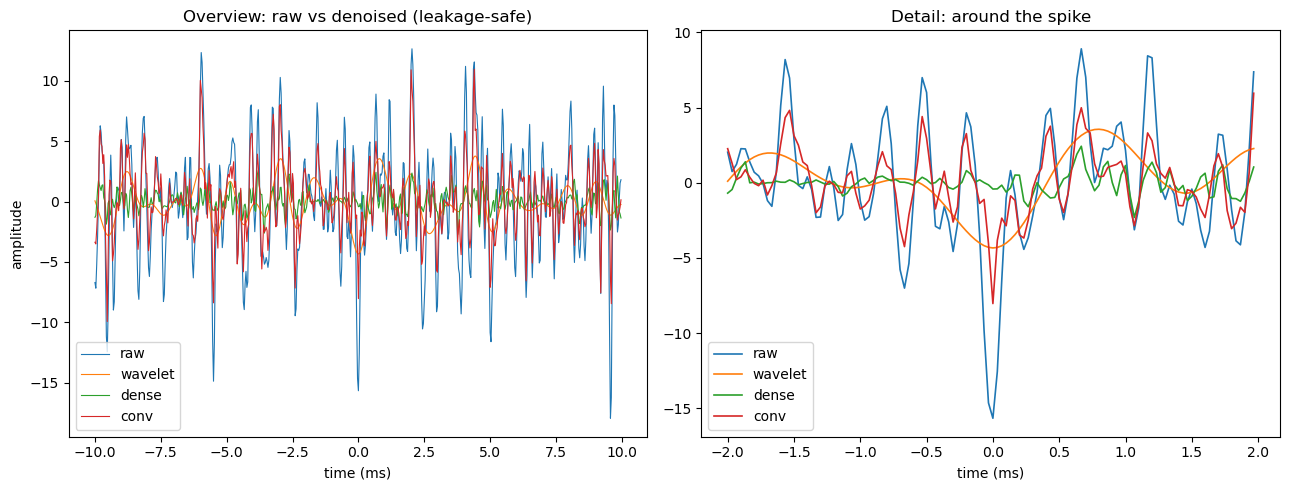

In [361]:
# Kechris style denoising figure, no leakage denoisers
example_spike_time = ground_truth_dev[10] # a dev spike
marked_position = int((example_spike_time - window_start) * sample_frequency)
align_window = 30
centre = np.argmin(ch19[marked_position-align_window:marked_position+align_window]) + (marked_position-align_window)

over_half = 300 # overview: ~10 ms each side
zoom_half = 60 # zoom: ~2 ms each side
signals = [("raw", ch19), ("wavelet", ch19_wavelet_dev), ("dense", ch19_dense_dev), ("conv", ch19_conv_dev)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left:overview
lo, hi = centre - over_half, centre + over_half
t_over = (np.arange(hi - lo) - over_half) / sample_frequency * 1000
for name, sig in signals:
    axes[0].plot(t_over, sig[lo:hi], linewidth=0.8, label=name)
axes[0].set_title("Overview: raw vs denoised (leakage-safe)")
axes[0].set_xlabel("time (ms)")
axes[0].set_ylabel("amplitude")
axes[0].legend()

#right: zoom
lo, hi = centre - zoom_half, centre + zoom_half
t_zoom = (np.arange(hi - lo) - zoom_half) / sample_frequency * 1000
for name, sig in signals:
    axes[1].plot(t_zoom, sig[lo:hi], linewidth=1.2, label=name)
axes[1].set_title("Detail: around the spike")
axes[1].set_xlabel("time (ms)")
axes[1].legend()
plt.savefig('C:/spike-denoising-synthetic/results/denoising_quality_leakage_safe.png', dpi=150)
plt.tight_layout()
plt.show()